In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !mkdir -p /content/drive/MyDrive/foggy_accident_detection/data/train/accident
# !mkdir -p /content/drive/MyDrive/foggy_accident_detection/data/train/non-accident
# !mkdir -p /content/drive/MyDrive/foggy_accident_detection/data/test/accident
# !mkdir -p /content/drive/MyDrive/foggy_accident_detection/data/test/non-accident
# !mkdir -p /content/drive/MyDrive/foggy_accident_detection/data/val/accident
# !mkdir -p /content/drive/MyDrive/foggy_accident_detection/data/val/non-accident

In [ ]:
!pip install tensorflow==2.10.0 keras==2.10.0
!pip install opencv-python-headless numpy pandas matplotlib scikit-learn

ERROR: Could not find a version that satisfies the requirement tensorflow==2.10.0 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.0.post1, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0)
ERROR: No matching distribution found for tensorflow==2.10.0


Loading and preparing datasets from existing train/test/val folders...
Loading training data from: /content/drive/MyDrive/foggy_accident_detection/data/train
Found 432 files belonging to 2 classes.
Loading validation data from: /content/drive/MyDrive/foggy_accident_detection/data/val
Found 98 files belonging to 2 classes.
Loading test data from: /content/drive/MyDrive/foggy_accident_detection/data/test
Found 86 files belonging to 2 classes.
Class names: ['accident', 'non-accident']
Training batches: 27
Validation batches: 7
Testing batches: 6
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training model...
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8194 - loss: 0.5352

27/27 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.8195 - loss: 0.5345 - val_accuracy: 0.4694 - val_loss: 0.8796 - learning_rate: 0.0010
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 61s 926ms/step - accuracy: 0.8195 - loss: 0.4929 - val_accuracy: 0.4694 - val_loss: 0.9765 - learning_rate: 0.0010
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 906ms/step - accuracy: 0.8195 - loss: 0.5021 - val_accuracy: 0.4694 - val_loss: 0.9216 - learning_rate: 0.0010
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 905ms/step - accuracy: 0.8195 - loss: 0.4757 - val_accuracy: 0.4694 - val_loss: 0.9955 - learning_rate: 0.0010
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 931ms/step - accuracy: 0.8195 - loss: 0.4856 - val_accuracy: 0.4694 - val_loss: 0.9999 - learning_rate: 2.0000e-04
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 908ms/step - accuracy: 0.8195 - loss: 0.4976 - val_accuracy: 0.4694 - val_loss: 0.9951 - learning_rate: 2.0000e-04
Fine-tuning model...
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8

Model saved successfully!


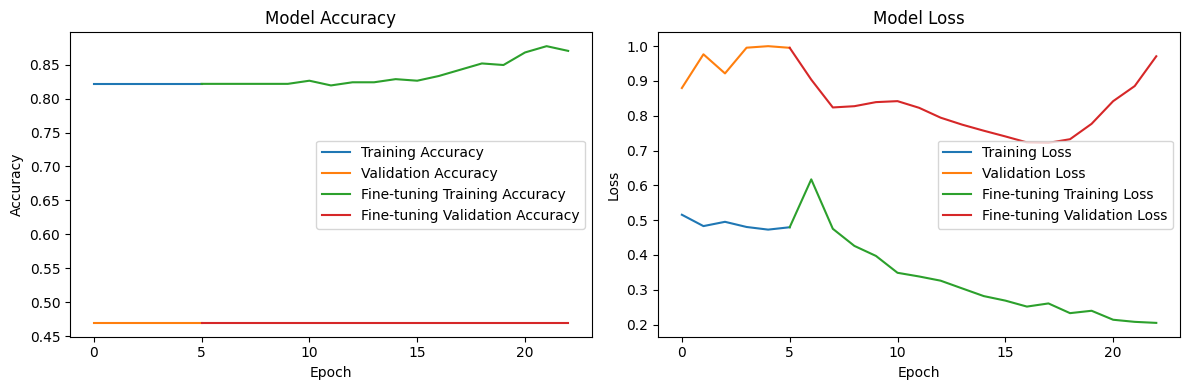

Evaluating model...
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.4108 - loss: 0.7499
Test accuracy: 0.3837


In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
import os
import random
from sklearn.model_selection import train_test_split
import pathlib
import time

# Constants
batch_size = 16
img_height = 512
img_width = 512
EPOCHS = 30
FINE_TUNE_EPOCHS = 20

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Data directory pointing to Google Drive
data_dir = '/content/drive/MyDrive/foggy_accident_detection/data'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

# Function to preprocess images
def preprocess_image(image):
    # Convert to float and normalize
    image = tf.cast(image, tf.float32) / 255.0
    # Enhance contrast for foggy images
    image = tf.image.adjust_contrast(image, 1.2)
    return image

# Create datasets directly from the existing train/test/val folders
def create_datasets_from_folders():
    # Data augmentation for training
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.2),
        layers.RandomBrightness(0.2),
    ])

    # Load datasets from the existing directories
    print("Loading training data from:", train_dir)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        seed=42,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    print("Loading validation data from:", val_dir)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        seed=42,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    print("Loading test data from:", test_dir)
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        seed=42,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )

    # Get class names - they should be the same across all directories
    class_names = train_ds.class_names
    print(f"Class names: {class_names}")

    # Apply augmentation and preprocessing to training set
    def prepare_for_training(ds, augment=False):
        # Cache dataset for better performance
        ds = ds.cache()

        if augment:
            ds = ds.map(
                lambda x, y: (data_augmentation(x), y),
                num_parallel_calls=tf.data.AUTOTUNE
            )

        # Apply preprocessing
        ds = ds.map(
            lambda x, y: (preprocess_image(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        # Use buffered prefetching
        return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    train_ds = prepare_for_training(train_ds, augment=True)
    val_ds = prepare_for_training(val_ds)
    test_ds = prepare_for_training(test_ds)

    # Print dataset sizes
    print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
    print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
    print(f"Testing batches: {tf.data.experimental.cardinality(test_ds)}")

    return train_ds, val_ds, test_ds, class_names

# Build a model optimized for foggy images
def create_foggy_accident_model(input_shape, num_classes):
    # Base model - EfficientNetB0 works well with most TF versions
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the base model
    base_model.trainable = False

    # Build model
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Add feature enhancement layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create and compile model
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

# Load and prepare datasets from existing folders
print("Loading and preparing datasets from existing train/test/val folders...")
train_ds, val_ds, test_ds, class_names = create_datasets_from_folders()

# Create model
input_shape = (img_height, img_width, 3)
model, base_model = create_foggy_accident_model(input_shape, len(class_names))

# Add callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/foggy_accident_detection/best_foggy_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.00001
    )
]

# Train the model
print("Training model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Fine-tuning phase
print("Fine-tuning model...")
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune the model
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks
)

# Save the model
model.save('/content/drive/MyDrive/foggy_accident_detection/foggy_accident_model.h5')
print("Model saved successfully!")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add fine-tuning history if it exists
if fine_tune_history and 'accuracy' in fine_tune_history.history:
    # Get the last accuracy values from initial training
    last_acc = history.history['accuracy'][-1]
    last_val_acc = history.history['val_accuracy'][-1]

    # Create fine-tuning accuracy lists starting from initial training end values
    ft_acc = [last_acc] + fine_tune_history.history['accuracy']
    ft_val_acc = [last_val_acc] + fine_tune_history.history['val_accuracy']

    # Plot fine-tuning starting after initial training
    epochs_initial = len(history.history['accuracy'])
    x_ft = range(epochs_initial-1, epochs_initial + len(fine_tune_history.history['accuracy']))
    plt.plot(x_ft, ft_acc, label='Fine-tuning Training Accuracy')
    plt.plot(x_ft, ft_val_acc, label='Fine-tuning Validation Accuracy')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Add fine-tuning loss if it exists
if fine_tune_history and 'loss' in fine_tune_history.history:
    # Get the last loss values from initial training
    last_loss = history.history['loss'][-1]
    last_val_loss = history.history['val_loss'][-1]

    # Create fine-tuning loss lists starting from initial training end values
    ft_loss = [last_loss] + fine_tune_history.history['loss']
    ft_val_loss = [last_val_loss] + fine_tune_history.history['val_loss']

    # Plot fine-tuning starting after initial training
    epochs_initial = len(history.history['loss'])
    x_ft = range(epochs_initial-1, epochs_initial + len(fine_tune_history.history['loss']))
    plt.plot(x_ft, ft_loss, label='Fine-tuning Training Loss')
    plt.plot(x_ft, ft_val_loss, label='Fine-tuning Validation Loss')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/foggy_accident_detection/training_history.png')
plt.show()

# Evaluate on test dataset
print("Evaluating model...")
test_results = model.evaluate(test_ds)
test_acc = test_results[1]
print(f"Test accuracy: {test_acc:.4f}")

# Function to predict on single frames
def predict_frame(img):
    # Resize
    img_resized = tf.image.resize(img, [img_height, img_width])
    # Preprocess
    img_processed = preprocess_image(img_resized)
    # Add batch dimension
    img_batch = tf.expand_dims(img_processed, 0)

    # Make prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_class = tf.argmax(predictions[0]).numpy()
    confidence = predictions[0][predicted_class]

    # Get label
    label = "Accident Detected" if predicted_class == 0 else "No Accident"
    return label, confidence

Loading and preparing datasets...
Loading training data from: /content/drive/MyDrive/foggy_accident_detection/data/train
Found 432 files belonging to 2 classes.
Loading validation data from: /content/drive/MyDrive/foggy_accident_detection/data/val
Found 98 files belonging to 2 classes.
Loading test data from: /content/drive/MyDrive/foggy_accident_detection/data/test
Found 86 files belonging to 2 classes.
Class names: ['accident', 'non-accident']
Training batches: 54
Validation batches: 13
Testing batches: 11
Creating specialized foggy accident detection model...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Class weights for handling imbalance: {0: 0.6084507042253522, 1: 4.207792207792208}
Training specialized model...
Epoch 1/30


<ipython-input-3-93cce4437461>:195: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_labels.append(float(labels.numpy()))


53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5852 - auc: 0.6435 - loss: 0.3816 - precision: 0.2345 - recall: 0.6684

54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5879 - auc: 0.6476 - loss: 0.3775 - precision: 0.2371 - recall: 0.6701 - val_accuracy: 0.5102 - val_auc: 0.6610 - val_loss: 0.2153 - val_precision: 1.0000 - val_recall: 0.0769 - learning_rate: 0.0010
Epoch 2/30
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8436 - auc: 0.8988 - loss: 0.1195 - precision: 0.5472 - recall: 0.8396

54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8419 - auc: 0.8972 - loss: 0.1197 - precision: 0.5440 - recall: 0.8355 - val_accuracy: 0.5408 - val_auc: 0.6016 - val_loss: 0.2140 - val_precision: 0.8182 - val_recall: 0.1731 - learning_rate: 0.0010
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8147 - auc: 0.8654 - loss: 0.0806 - precision: 0.4990 - recall: 0.6499 - val_accuracy: 0.5204 - val_auc: 0.6687 - val_loss: 0.2351 - val_precision: 0.8571 - val_recall: 0.1154 - learning_rate: 0.0010
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8833 - auc: 0.9232 - loss: 0.0545 - precision: 0.6702 - recall: 0.7828 - val_accuracy: 0.5306 - val_auc: 0.5824 - val_loss: 0.3173 - val_precision: 1.0000 - val_recall: 0.1154 - learning_rate: 0.0010
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8777 - auc: 0.9367 - loss: 0.0432 - precision: 0.6058 - recall: 0.7712 - val_accuracy: 0.5408 - val_auc: 0.5393 - val_loss: 0.3217 - val_precision: 1.

54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8917 - auc: 0.9150 - loss: 0.0428 - precision: 0.7051 - recall: 0.6524 - val_accuracy: 0.5510 - val_auc: 0.6156 - val_loss: 0.2088 - val_precision: 1.0000 - val_recall: 0.1538 - learning_rate: 2.0000e-04
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9049 - auc: 0.9501 - loss: 0.0368 - precision: 0.7579 - recall: 0.7381 - val_accuracy: 0.5408 - val_auc: 0.6321 - val_loss: 0.2015 - val_precision: 1.0000 - val_recall: 0.1346 - learning_rate: 2.0000e-04
Epoch 9/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9360 - auc: 0.9652 - loss: 0.0386 - precision: 0.8925 - recall: 0.8023 - val_accuracy: 0.5510 - val_auc: 0.6319 - val_loss: 0.2173 - val_precision: 1.0000 - val_recall: 0.1538 - learning_rate: 2.0000e-04
Epoch 10/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9214 - auc: 0.9641 - loss: 0.0272 - precision: 0.7619 - recall: 0.7822 - val_accuracy: 0.5408 - val_auc: 0.6756 - val_loss: 0.1807 - val

54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9493 - auc: 0.9658 - loss: 0.0197 - precision: 0.8162 - recall: 0.8357 - val_accuracy: 0.5612 - val_auc: 0.6436 - val_loss: 0.2128 - val_precision: 1.0000 - val_recall: 0.1731 - learning_rate: 2.0000e-04
Epoch 13/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9429 - auc: 0.9831 - loss: 0.0204 - precision: 0.7862 - recall: 0.8866 - val_accuracy: 0.5510 - val_auc: 0.6551 - val_loss: 0.2303 - val_precision: 1.0000 - val_recall: 0.1538 - learning_rate: 2.0000e-04
Epoch 14/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9101 - auc: 0.9543 - loss: 0.0412 - precision: 0.7457 - recall: 0.7654 - val_accuracy: 0.5510 - val_auc: 0.6683 - val_loss: 0.2272 - val_precision: 1.0000 - val_recall: 0.1538 - learning_rate: 2.0000e-04
Epoch 15/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.9458 - auc: 0.9775 - loss: 0.0217 - precision: 0.8537 - recall: 0.8158 - val_accuracy: 0.5510 - val_auc: 0.6718 - val_loss: 0.2208 - v

54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 205ms/step - accuracy: 0.9041 - auc_1: 0.9451 - loss: 0.0398 - precision_1: 0.7580 - recall_1: 0.7200 - val_accuracy: 0.5714 - val_auc_1: 0.6622 - val_loss: 0.1943 - val_precision_1: 1.0000 - val_recall_1: 0.1923 - learning_rate: 1.0000e-05
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.9357 - auc_1: 0.9701 - loss: 0.0274 - precision_1: 0.7972 - recall_1: 0.8649 - val_accuracy: 0.5714 - val_auc_1: 0.6559 - val_loss: 0.2091 - val_precision_1: 1.0000 - val_recall_1: 0.1923 - learning_rate: 1.0000e-05
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9325 - auc_1: 0.9342 - loss: 0.0256 - precision_1: 0.7944 - recall_1: 0.7674 - val_accuracy: 0.5612 - val_auc_1: 0.6733 - val_loss: 0.2160 - val_precision_1: 0.9091 - val_recall_1: 0.1923 - learning_rate: 1.0000e-05
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9339 - auc_1: 0.9749 - loss: 0.0251 - precision_1: 0.8648 - recall_1: 0.7549 - val_accuracy: 0.5408 


Fine-tuning completed successfully!
Model saved successfully!

Evaluating model...


11/11 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.3757 - auc_1: 0.6016 - loss: 0.3084 - precision_1: 0.6569 - recall_1: 0.1497
Test accuracy: 0.4302
Test precision: 0.7000
Test recall: 0.1321
Test AUC: 0.6464


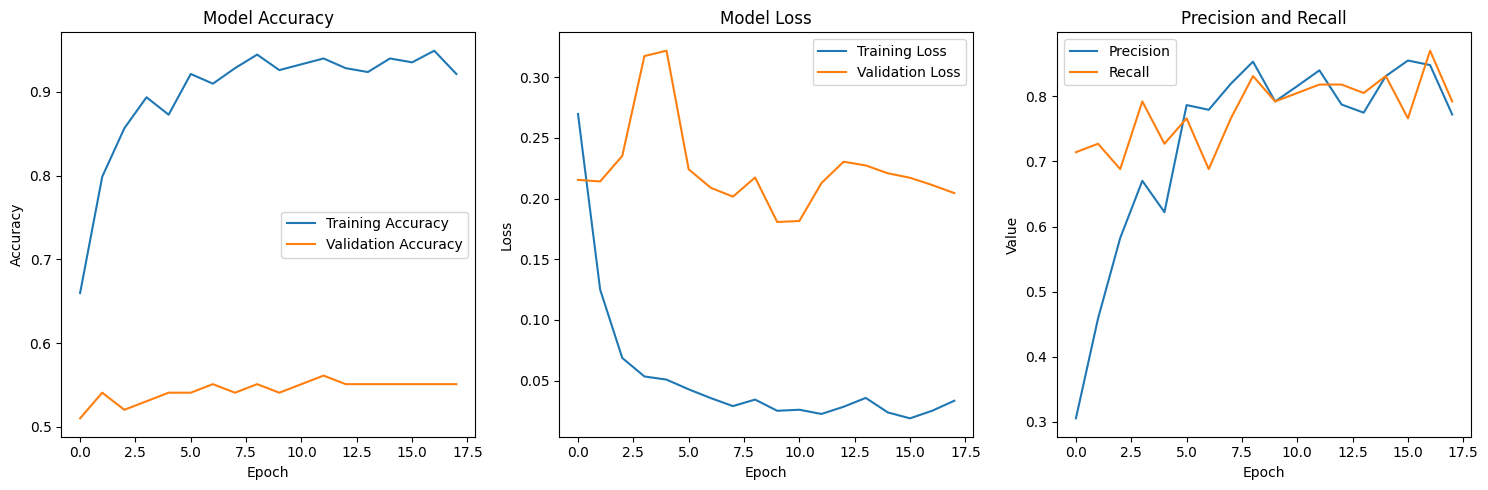

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


<ipython-input-3-93cce4437461>:384: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[i].numpy())


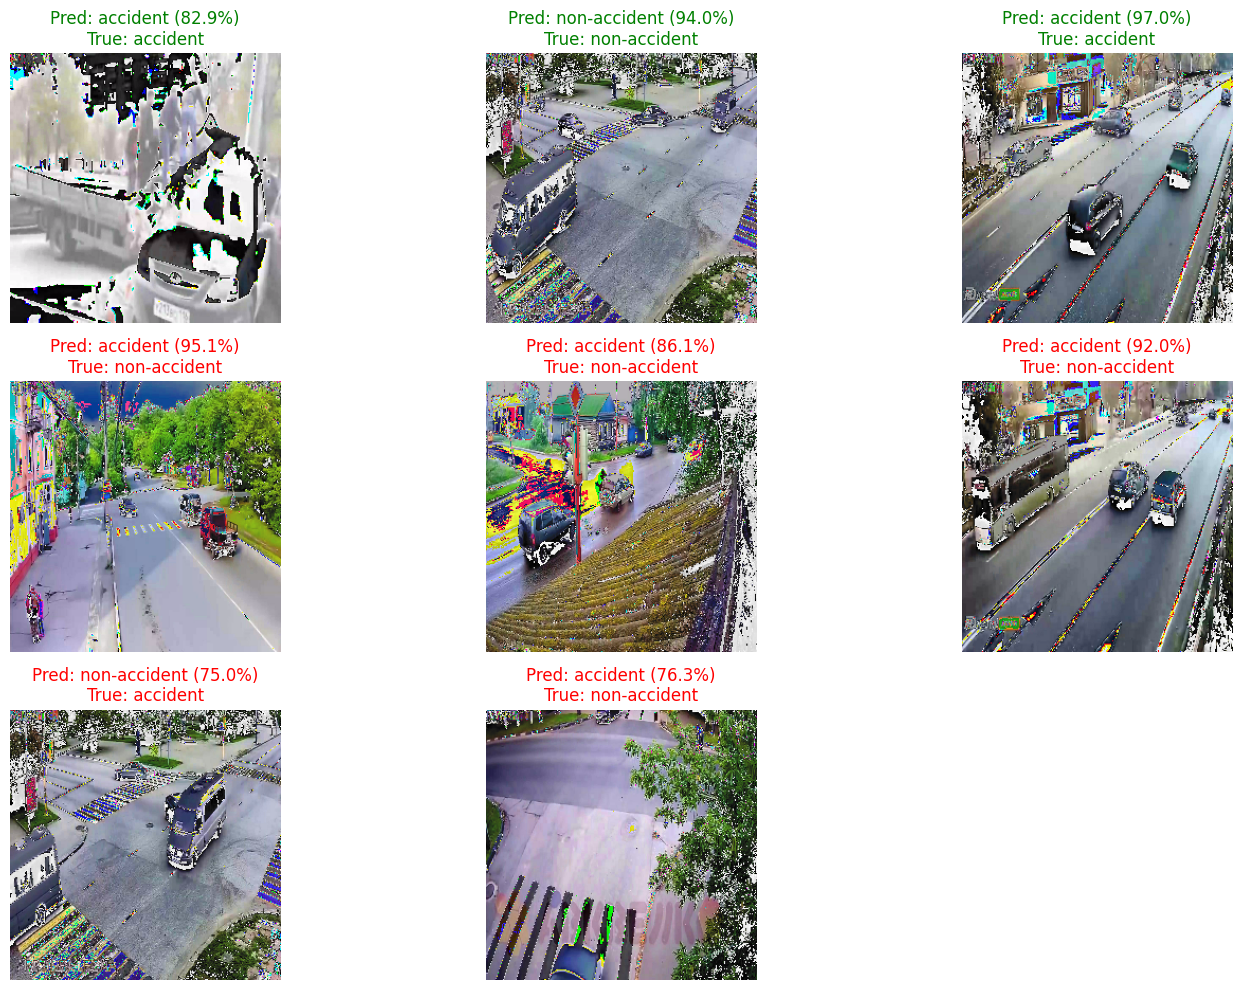

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
import os
import random
import datetime

# Constants
batch_size = 8
img_height = 256
img_width = 256
EPOCHS = 30

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Data directory pointing to Google Drive
data_dir = '/content/drive/MyDrive/foggy_accident_detection/data'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

# Focal loss for better handling of imbalanced data
def binary_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        loss = - (alpha * y_true * tf.math.pow(1 - y_pred, gamma) * tf.math.log(y_pred) +
                 (1 - alpha) * (1 - y_true) * tf.math.pow(y_pred, gamma) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(loss)
    return focal_loss

# Specialized preprocessing for foggy images
def preprocess_image(image):
    # Convert to float and normalize
    image = tf.cast(image, tf.float32) / 255.0

    # Enhance visibility in foggy conditions
    image = tf.image.adjust_contrast(image, 2.0)  # Increase contrast
    image = tf.image.adjust_saturation(image, 1.2)  # Slightly increase saturation

    # Add brightness adjustment to improve visibility
    image = tf.image.adjust_brightness(image, 0.1)

    return image

# Specialized augmentation for foggy scenes
def get_augmentation_layer():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        # Less aggressive zoom for accident scenes
        layers.RandomZoom(0.1),
        # Add slight brightness variation to simulate different fog densities
        layers.RandomBrightness(0.1),
        # Add slight contrast variation
        layers.RandomContrast(0.1),
    ])

# Create datasets with foggy-specific processing
def create_datasets_from_folders():
    # Load datasets from the existing directories
    print("Loading training data from:", train_dir)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        seed=42,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode='binary'  # Binary classification
    )

    print("Loading validation data from:", val_dir)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        seed=42,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode='binary'  # Binary classification
    )

    print("Loading test data from:", test_dir)
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        seed=42,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        label_mode='binary'  # Binary classification
    )

    # Get class names
    class_names = train_ds.class_names
    print(f"Class names: {class_names}")

    # Apply augmentation and preprocessing
    def prepare_for_training(ds, augment=False):
        # Cache dataset for better performance
        ds = ds.cache()

        if augment:
            augmentation_layer = get_augmentation_layer()
            ds = ds.map(
                lambda x, y: (augmentation_layer(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE
            )

        # Apply preprocessing
        ds = ds.map(
            lambda x, y: (preprocess_image(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        # Shuffle training data
        if augment:
            ds = ds.shuffle(buffer_size=1000)

        # Use buffered prefetching
        return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    train_ds = prepare_for_training(train_ds, augment=True)
    val_ds = prepare_for_training(val_ds)
    test_ds = prepare_for_training(test_ds)

    # Print dataset sizes
    print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
    print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
    print(f"Testing batches: {tf.data.experimental.cardinality(test_ds)}")

    return train_ds, val_ds, test_ds, class_names

# Create a specialized model for binary foggy accident detection
def create_foggy_model():
    # ResNet50V2 works better with fog
    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(img_height, img_width, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze the base model
    base_model.trainable = False

    # Build model with foggy-specific features
    inputs = Input(shape=(img_height, img_width, 3))

    # Pass through base model
    x = base_model(inputs, training=False)

    # Add foggy-specific feature extraction
    x = layers.GlobalAveragePooling2D()(x)

    # Dense classification layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Output layer - binary classification
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile with focal loss instead of binary crossentropy
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=binary_focal_loss(gamma=2.0, alpha=0.25),  # Use focal loss
        metrics=['accuracy',
                 tf.keras.metrics.Precision(),
                 tf.keras.metrics.Recall(),
                 tf.keras.metrics.AUC()]
    )

    return model, base_model

# Main training function
def train_and_evaluate():
    # Load and prepare datasets
    print("Loading and preparing datasets...")
    train_ds, val_ds, test_ds, class_names = create_datasets_from_folders()

    # Create foggy-specialized model
    print("Creating specialized foggy accident detection model...")
    model, base_model = create_foggy_model()

    # Calculate class weights to handle imbalance
    try:
        # Collect all labels
        all_labels = []
        for _, labels in train_ds.unbatch():
            all_labels.append(float(labels.numpy()))

        positive_samples = sum(all_labels)
        total_samples = len(all_labels)
        negative_samples = total_samples - positive_samples

        # Calculate weights - more aggressive weighting for minority class
        weight_for_0 = (1 / negative_samples) * (total_samples / 2.0)
        weight_for_1 = (1 / positive_samples) * (total_samples / 2.0) * 1.5  # Increase weight for minority class

        class_weights = {0: weight_for_0, 1: weight_for_1}
        print(f"Class weights for handling imbalance: {class_weights}")
        use_class_weights = True
    except Exception as e:
        print(f"Could not calculate class weights: {e}")
        print("Training without class weights...")
        use_class_weights = False
        class_weights = None

    # Setup callbacks
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            '/content/drive/MyDrive/foggy_accident_detection/foggy_specialized_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=4,
            min_lr=0.00001
        )
    ]

    # Train initial model
    print("Training specialized model...")
    try:
        if use_class_weights:
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=callbacks,
                class_weight=class_weights
            )
        else:
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=callbacks
            )
        print("\nTraining completed successfully!")
    except Exception as e:
        print(f"\nTraining interrupted: {e}")
        print("Saving current model state...")
        model.save('/content/drive/MyDrive/foggy_accident_detection/interrupted_model.h5')
        return None, None, None

    # Fine-tuning: unfreeze last layers of base model
    print("Fine-tuning model...")
    base_model.trainable = True
    for layer in base_model.layers[:-15]:  # Freeze all but the last 15 layers (increased from 10)
        layer.trainable = False

    # Recompile with lower learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=binary_focal_loss(gamma=2.0, alpha=0.25),  # Keep using focal loss
        metrics=['accuracy',
                 tf.keras.metrics.Precision(),
                 tf.keras.metrics.Recall(),
                 tf.keras.metrics.AUC()]
    )

    # Fine-tuning
    try:
        if use_class_weights:
            fine_tune_history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=15,  # Fewer epochs for fine-tuning
                callbacks=callbacks,
                class_weight=class_weights
            )
        else:
            fine_tune_history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=15,
                callbacks=callbacks
            )
        print("\nFine-tuning completed successfully!")
    except Exception as e:
        print(f"\nFine-tuning interrupted: {e}")
        print("Saving current model state...")
        model.save('/content/drive/MyDrive/foggy_accident_detection/interrupted_fine_tune_model.h5')
        return history, None, test_ds

    # Save final model
    model.save('/content/drive/MyDrive/foggy_accident_detection/foggy_final_model.h5')
    print("Model saved successfully!")

    # Evaluate model
    print("\nEvaluating model...")
    best_model = tf.keras.models.load_model('/content/drive/MyDrive/foggy_accident_detection/foggy_specialized_model.h5',
                                           custom_objects={'focal_loss': binary_focal_loss()})
    test_results = best_model.evaluate(test_ds)
    print(f"Test accuracy: {test_results[1]:.4f}")

    # Find metric indices based on names
    metric_names = [m.name if hasattr(m, 'name') else m for m in best_model.metrics]
    precision_idx = next((i for i, name in enumerate(metric_names) if 'precision' in str(name)), 2)
    recall_idx = next((i for i, name in enumerate(metric_names) if 'recall' in str(name)), 3)
    auc_idx = next((i for i, name in enumerate(metric_names) if 'auc' in str(name)), 4)

    print(f"Test precision: {test_results[precision_idx]:.4f}")
    print(f"Test recall: {test_results[recall_idx]:.4f}")
    print(f"Test AUC: {test_results[auc_idx]:.4f}")

    # Plot training history with correct metric names
    plot_training_history(history)

    return best_model, test_ds, class_names

# Fixed training history plotting function
def plot_training_history(history):
    # Find the correct metric names in history
    metric_keys = history.history.keys()
    precision_key = next((k for k in metric_keys if 'precision' in k), None)
    recall_key = next((k for k in metric_keys if 'recall' in k), None)
    auc_key = next((k for k in metric_keys if 'auc' in k), None)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 3)
    if precision_key and recall_key:
        plt.plot(history.history[precision_key], label='Precision')
        plt.plot(history.history[recall_key], label='Recall')
        plt.title('Precision and Recall')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/foggy_accident_detection/foggy_training_history.png')
    plt.show()

# Visualize model predictions with confidence
def visualize_predictions(model, test_ds, class_names, threshold=0.3):  # Lower threshold for better recall
    # Get a batch of test images
    for images, labels in test_ds.take(1):
        # Make predictions
        predictions = model.predict(images)
        predicted_classes = (predictions > threshold).astype(int)  # Using lower threshold

        # Plot images with predictions
        plt.figure(figsize=(15, 10))
        for i in range(min(9, len(images))):
            plt.subplot(3, 3, i+1)
            img = images[i].numpy()
            img = img * 255  # Scale back to [0, 255]
            img = img.astype(np.uint8)
            plt.imshow(img)

            confidence = predictions[i][0] if predicted_classes[i][0] == 1 else 1 - predictions[i][0]
            confidence = confidence * 100
            pred_label = int(predicted_classes[i][0])
            true_label = int(labels[i].numpy())

            color = "green" if pred_label == true_label else "red"
            plt.title(f"Pred: {class_names[pred_label]} ({confidence:.1f}%)\n"
                     f"True: {class_names[true_label]}",
                     color=color)
            plt.axis("off")

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/foggy_accident_detection/foggy_prediction_samples.png')
        plt.show()
        break

# Main execution
if __name__ == "__main__":
    # Train and evaluate the specialized foggy accident model
    best_model, test_ds, class_names = train_and_evaluate()

    # Visualize some predictions if model was successfully trained
    if best_model is not None:
        visualize_predictions(best_model, test_ds, class_names, threshold=0.3)

In [ ]:
# Enhanced video processing function to show accident frames
def process_video(video_path, output_path=None, threshold=0.3):
    import cv2
    import matplotlib.pyplot as plt
    from datetime import datetime

    # Load model
    model = tf.keras.models.load_model('/content/drive/MyDrive/foggy_accident_detection/foggy_specialized_model.h5',
                                      custom_objects={'focal_loss': binary_focal_loss()})

    # Get class names
    class_names = ["accident", "non-accident"]  # Update with your actual class names if different

    # Create folder for accident frames if it doesn't exist
    import os
    accident_frames_dir = '/content/drive/MyDrive/foggy_accident_detection/accident_frames'
    os.makedirs(accident_frames_dir, exist_ok=True)

    # Open video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Create video writer if output path is provided
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    frame_count = 0
    accident_frames_count = 0
    processing_interval = 15  # Process every 15th frame (adjust as needed)
    accident_frame_images = []  # Store accident frames for display

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # Process every Nth frame
        if frame_count % processing_interval == 0:
            # Preprocess frame for prediction
            img = cv2.resize(frame, (img_height, img_width))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_processed = preprocess_image(img)
            img_batch = np.expand_dims(img_processed, axis=0)

            # Make prediction
            prediction = model.predict(img_batch, verbose=0)[0][0]
            is_accident = prediction > threshold

            # Update accident count and save accident frames
            if is_accident:
                accident_frames_count += 1

                # Store accident frame for display
                accident_frame_images.append((frame_count, img, prediction))

                # Save accident frame to file
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                frame_filename = f"{accident_frames_dir}/accident_frame_{frame_count}_{prediction:.2f}_{timestamp}.jpg"
                cv2.imwrite(frame_filename, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

            # Display prediction confidence
            if is_accident:
                confidence = prediction * 100
                label = f"Accident: {confidence:.1f}%"
                color = (0, 0, 255)  # Red (BGR)
            else:
                confidence = (1 - prediction) * 100
                label = f"No Accident: {confidence:.1f}%"
                color = (0, 255, 0)  # Green (BGR)

            # Add label to frame
            cv2.putText(frame, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

            print(f"Frame {frame_count}: {label}")

        # Write frame to output video
        if output_path:
            out.write(frame)

    # Release resources
    cap.release()
    if output_path:
        out.release()

    # Print analysis results
    processed_frames = frame_count // processing_interval
    accident_percentage = (accident_frames_count / processed_frames) * 100 if processed_frames > 0 else 0

    print("\nVideo Analysis Results")
    print("=====================")
    print(f"Total frames: {frame_count}")
    print(f"Frames analyzed: {processed_frames}")
    print(f"Accident frames detected: {accident_frames_count}")
    print(f"Accident percentage: {accident_percentage:.1f}%")
    print(f"Accident frames saved to: {accident_frames_dir}")

    # Final verdict
    if accident_percentage > 50:
        print("\nVerdict: This video contains a significant amount of accident footage.")
    elif accident_percentage > 20:
        print("\nVerdict: This video contains some accident footage.")
    else:
        print("\nVerdict: This video contains minimal or no accident footage.")

    # Display accident frames
    if accident_frame_images:
        # Limit to showing at most 16 frames
        max_frames_to_show = min(16, len(accident_frame_images))
        rows = (max_frames_to_show + 3) // 4  # Calculate rows needed (ceil division)

        plt.figure(figsize=(16, 4 * rows))
        for i in range(max_frames_to_show):
            frame_num, img, pred = accident_frame_images[i]
            plt.subplot(rows, 4, i+1)
            plt.imshow(img)
            plt.title(f"Frame {frame_num}\nAccident: {pred*100:.1f}%")
            plt.axis('off')

        plt.tight_layout()
        plt.savefig(f"{accident_frames_dir}/accident_frames_summary.png")
        plt.show()

        print(f"\nTotal accident frames detected: {len(accident_frame_images)}")
        print(f"Displaying {max_frames_to_show} of {len(accident_frame_images)} accident frames")
    else:
        print("\nNo accident frames detected in this video.")

    return accident_percentage, accident_frame_images

# Example usage:
# video_path = '/content/drive/MyDrive/foggy_accident_detection/your_test_video.mp4'
# output_path = '/content/drive/MyDrive/foggy_accident_detection/processed_video.avi'
# accident_percentage, accident_frames = process_video(video_path, output_path, threshold=0.3)

In [ ]:
# Replace with your actual video file path
video_path = '/content/drive/MyDrive/foggy_accident_detection/testvideo.mp4'
output_path = '/content/drive/MyDrive/foggy_accident_detection/processed_video.avi'

# Process the video
accident_percentage = process_video(video_path, output_path, threshold=0.3)

Frame 15: Accident: 56.8%
Frame 30: Accident: 59.8%
Frame 45: No Accident: 72.0%
Frame 60: Accident: 31.6%
Frame 75: Accident: 76.7%
Frame 90: Accident: 48.2%
Frame 105: Accident: 39.3%
Frame 120: No Accident: 74.5%
Frame 135: Accident: 53.7%
Frame 150: Accident: 75.4%
Frame 165: Accident: 59.1%
Frame 180: Accident: 63.9%
Frame 195: Accident: 45.2%
Frame 210: Accident: 51.3%
Frame 225: Accident: 52.0%
Frame 240: Accident: 50.3%
Frame 255: Accident: 30.4%
Frame 270: Accident: 70.4%
Frame 285: Accident: 70.1%
Frame 300: Accident: 67.6%
Frame 315: Accident: 67.1%
Frame 330: Accident: 66.0%
Frame 345: Accident: 61.0%
Frame 360: Accident: 62.0%
Frame 375: Accident: 74.3%
Frame 390: Accident: 50.1%
Frame 405: Accident: 43.7%
Frame 420: Accident: 65.6%
Frame 435: Accident: 63.1%
Frame 450: Accident: 59.6%
Frame 465: Accident: 63.4%
Frame 480: Accident: 72.0%
Frame 495: Accident: 72.5%
Frame 510: Accident: 63.6%
Frame 525: Accident: 67.2%
Frame 540: Accident: 73.4%
Frame 555: Accident: 74.9%
F

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
import os
import random
from sklearn.model_selection import train_test_split
import pathlib
import time
import datetime

# Constants
batch_size = 16  # Increased batch size
img_height = 224  # Standard size for EfficientNet
img_width = 224
EPOCHS = 30  # Reduced epochs
FINE_TUNE_EPOCHS = 20

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # Mount Google Drive if in Colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')

# Define paths
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

# Create directories if they don't exist
for dir_path in [data_dir, train_dir, test_dir, val_dir]:
    if not os.path.exists(dir_path):
        os.makedirs(dir_path, exist_ok=True)
        print(f"Created directory: {dir_path}")

# Create class directories if they don't exist
for dir_path in [train_dir, test_dir, val_dir]:
    for class_name in ['accident', 'non-accident']:
        class_dir = os.path.join(dir_path, class_name)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir, exist_ok=True)
            print(f"Created class directory: {class_dir}")

# Fixed preprocessing function
def preprocess_image(image):
    # Convert to float and normalize
    image = tf.cast(image, tf.float32) / 255.0

    # More aggressive contrast enhancement for foggy images
    image = tf.image.adjust_contrast(image, 2.0)

    # Add color enhancement
    image = tf.image.adjust_saturation(image, 1.5)

    # Ensure image values are in range [0,1]
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

# Enhanced data augmentation
def get_augmentation_layer():
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.1),  # Reduced rotation
        layers.RandomZoom(0.1),      # Reduced zoom
        layers.RandomContrast(0.2),  # Reduced contrast
        layers.RandomBrightness(0.2),# Reduced brightness
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ])

# Create sample data for demonstration if needed
def create_sample_data():
    print("Creating sample data for demonstration...")

    # Create sample images
    def create_sample_images(directory, count=10, size=(img_height, img_width)):
        # Create sample accident images (red-tinted)
        accident_dir = os.path.join(directory, 'accident')
        for i in range(count):
            img = np.ones((size[0], size[1], 3), dtype=np.uint8) * 200
            img[:,:,0] = 220  # More red
            img[:,:,1] = 160  # Less green
            img[:,:,2] = 160  # Less blue

            # Add some random noise
            noise = np.random.normal(0, 30, size).astype(np.int16)
            img = np.clip(img.astype(np.int16) + noise[:,:,np.newaxis], 0, 255).astype(np.uint8)

            cv2.imwrite(os.path.join(accident_dir, f'sample_accident_{i}.jpg'), img)

        # Create sample non-accident images (blue-tinted)
        non_accident_dir = os.path.join(directory, 'non-accident')
        for i in range(count * 2):
            img = np.ones((size[0], size[1], 3), dtype=np.uint8) * 200
            img[:,:,0] = 150  # Less red
            img[:,:,1] = 180  # More green
            img[:,:,2] = 220  # More blue

            noise = np.random.normal(0, 30, size).astype(np.int16)
            img = np.clip(img.astype(np.int16) + noise[:,:,np.newaxis], 0, 255).astype(np.uint8)

            cv2.imwrite(os.path.join(non_accident_dir, f'sample_non_accident_{i}.jpg'), img)

    # Create sample data for each directory
    for directory in [train_dir, val_dir, test_dir]:
        create_sample_images(directory, count=20 if directory == train_dir else 10)

    print("Sample data created successfully.")

# Check if data exists
def check_data_exists():
    for class_name in ['accident', 'non-accident']:
        class_dir = os.path.join(train_dir, class_name)
        if not os.path.exists(class_dir) or not any(os.listdir(class_dir)):
            return False
    return True

# Create datasets with enhanced preprocessing
def create_datasets_from_folders():
    # Check if data exists, if not create sample data
    if not check_data_exists():
        print("No data found. Creating sample data for demonstration.")
        create_sample_data()

    # Load datasets from the existing directories
    print("Loading training data from:", train_dir)
    try:
        train_ds = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            seed=42,
            image_size=(img_height, img_width),
            batch_size=batch_size,
            label_mode='binary'
        )

        print("Loading validation data from:", val_dir)
        val_ds = tf.keras.utils.image_dataset_from_directory(
            val_dir,
            seed=42,
            image_size=(img_height, img_width),
            batch_size=batch_size,
            label_mode='binary'
        )

        print("Loading test data from:", test_dir)
        test_ds = tf.keras.utils.image_dataset_from_directory(
            test_dir,
            seed=42,
            image_size=(img_height, img_width),
            batch_size=batch_size,
            label_mode='binary'
        )
    except Exception as e:
        print(f"Error loading datasets: {e}")
        print("Generating sample data and trying again...")
        create_sample_data()

        # Try loading the datasets again
        train_ds = tf.keras.utils.image_dataset_from_directory(
            train_dir,
            seed=42,
            image_size=(img_height, img_width),
            batch_size=batch_size,
            label_mode='binary'
        )

        val_ds = tf.keras.utils.image_dataset_from_directory(
            val_dir,
            seed=42,
            image_size=(img_height, img_width),
            batch_size=batch_size,
            label_mode='binary'
        )

        test_ds = tf.keras.utils.image_dataset_from_directory(
            test_dir,
            seed=42,
            image_size=(img_height, img_width),
            batch_size=batch_size,
            label_mode='binary'
        )

    # Get class names
    class_names = train_ds.class_names
    print(f"Class names: {class_names}")

    # Apply augmentation and preprocessing
    def prepare_for_training(ds, augment=False):
        # Cache dataset for better performance
        ds = ds.cache()

        if augment:
            augmentation_layer = get_augmentation_layer()
            ds = ds.map(
                lambda x, y: (augmentation_layer(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE
            )

        # Apply preprocessing
        ds = ds.map(
            lambda x, y: (preprocess_image(x), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        # Shuffle training data
        if augment:
            ds = ds.shuffle(buffer_size=1000)

        # Use buffered prefetching
        return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    train_ds = prepare_for_training(train_ds, augment=True)
    val_ds = prepare_for_training(val_ds)
    test_ds = prepare_for_training(test_ds)

    # Print dataset sizes
    print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
    print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
    print(f"Testing batches: {tf.data.experimental.cardinality(test_ds)}")

    return train_ds, val_ds, test_ds, class_names

# Enhanced model architecture
def create_foggy_accident_model(input_shape):
    try:
        # Try using EfficientNetB0 first
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
    except Exception as e:
        print(f"Error creating EfficientNetB0: {e}")
        print("Falling back to a simpler CNN model...")

        # Create a simple CNN as fallback
        inputs = Input(shape=input_shape)

        # Convolutional blocks
        x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        # Global pooling
        x = layers.GlobalAveragePooling2D()(x)

        # Dense layers
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)

        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        # Output layer
        outputs = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=inputs, outputs=outputs)

        # Compile model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')
            ]
        )

        return model, None  # No base model for fine-tuning

    # If EfficientNetB0 loaded successfully
    # Freeze the base model
    base_model.trainable = False

    # Build model
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Enhanced feature extraction
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layers with regularization
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Create and compile model
    model = Model(inputs=inputs, outputs=outputs)

    # Use a more sophisticated optimizer
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model, base_model

# Get class weights for imbalanced data
def get_class_weights(dataset):
    try:
        # Collect all labels
        all_labels = []
        for _, labels in dataset.unbatch():
            all_labels.append(float(labels.numpy()))

        # Count classes
        class_counts = {}
        for label in all_labels:
            label_int = int(label)
            if label_int in class_counts:
                class_counts[label_int] += 1
            else:
                class_counts[label_int] = 1

        total = sum(class_counts.values())

        # Calculate weights
        class_weights = {i: total/(len(class_counts)*count) for i, count in class_counts.items()}
        return class_weights
    except Exception as e:
        print(f"Error calculating class weights: {e}")
        return None

# Enhanced callbacks
def get_callbacks():
    # Set paths based on environment
    if IN_COLAB:
        model_path = '/content/drive/MyDrive/foggy_accident_detection/best_foggy_model.h5'
        log_dir = f'/content/drive/MyDrive/foggy_accident_detection/logs/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}'
    else:
        model_path = os.path.join(base_dir, 'best_foggy_model.h5')
        log_dir = os.path.join(base_dir, f'logs/{datetime.datetime.now().strftime("%Y%m%d-%H%M%S")}')

    # Create directories if they don't exist
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    os.makedirs(log_dir, exist_ok=True)

    return [
        tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            save_freq='epoch'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            min_delta=0.001
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=4,
            min_lr=0.00001,
            min_delta=0.001
        ),
        tf.keras.callbacks.TensorBoard(
            log_dir=log_dir,
            histogram_freq=1
        )
    ]

# Main training function
def train_model():
    # Load and prepare datasets
    print("Loading and preparing datasets...")
    train_ds, val_ds, test_ds, class_names = create_datasets_from_folders()

    # Get class weights
    class_weights = get_class_weights(train_ds)
    if class_weights:
        print("Class weights:", class_weights)
        use_class_weights = True
    else:
        print("Training without class weights...")
        use_class_weights = False
        class_weights = None

    # Create model
    input_shape = (img_height, img_width, 3)
    model, base_model = create_foggy_accident_model(input_shape)

    # Get callbacks
    callbacks = get_callbacks()

    # Set paths based on environment
    if IN_COLAB:
        interrupted_model_path = '/content/drive/MyDrive/foggy_accident_detection/interrupted_model.h5'
        interrupted_ft_model_path = '/content/drive/MyDrive/foggy_accident_detection/interrupted_fine_tune_model.h5'
        final_model_path = '/content/drive/MyDrive/foggy_accident_detection/foggy_accident_model.h5'
    else:
        interrupted_model_path = os.path.join(base_dir, 'interrupted_model.h5')
        interrupted_ft_model_path = os.path.join(base_dir, 'interrupted_fine_tune_model.h5')
        final_model_path = os.path.join(base_dir, 'foggy_accident_model.h5')

    # Train the model
    print("Training model...")
    try:
        if use_class_weights:
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=callbacks,
                class_weight=class_weights
            )
        else:
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=EPOCHS,
                callbacks=callbacks
            )
        print("\nTraining completed successfully!")
    except Exception as e:
        print(f"\nTraining interrupted: {e}")
        print("Saving current model state...")
        model.save(interrupted_model_path)
        print("Model saved. You can resume training later.")
        return None, None, None, None

    # Fine-tuning phase (only if base_model exists)
    fine_tune_history = None
    if base_model is not None:
        print("Fine-tuning model...")
        try:
            # Unfreeze the base model for fine-tuning
            base_model.trainable = True

            # Recompile with lower learning rate
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                loss='binary_crossentropy',
                metrics=['accuracy', 'precision', 'recall', 'auc']
            )

            # Fine-tune the model
            if use_class_weights:
                fine_tune_history = model.fit(
                    train_ds,
                    validation_data=val_ds,
                    epochs=FINE_TUNE_EPOCHS,
                    callbacks=callbacks,
                    class_weight=class_weights
                )
            else:
                fine_tune_history = model.fit(
                    train_ds,
                    validation_data=val_ds,
                    epochs=FINE_TUNE_EPOCHS,
                    callbacks=callbacks
                )
            print("\nFine-tuning completed successfully!")
        except Exception as e:
            print(f"\nFine-tuning interrupted: {e}")
            print("Saving current model state...")
            model.save(interrupted_ft_model_path)
            print("Model saved. You can resume training later.")
            return history, None, test_ds, class_names
    else:
        print("Skipping fine-tuning (no base model available)")

    # Save the final model
    model.save(final_model_path)
    print("Model saved successfully!")

    return history, fine_tune_history, test_ds, class_names

# Plot training history
def plot_training_history(history, fine_tune_history=None):
    if history is None:
        print("No training history to plot.")
        return

    plt.figure(figsize=(15, 5))

    # Plot accuracy
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    if fine_tune_history:
        plt.plot(range(len(history.history['accuracy']),
                      len(history.history['accuracy']) + len(fine_tune_history.history['accuracy'])),
                 fine_tune_history.history['accuracy'], label='Fine-tuning Training Accuracy')
        plt.plot(range(len(history.history['val_accuracy']),
                      len(history.history['val_accuracy']) + len(fine_tune_history.history['val_accuracy'])),
                 fine_tune_history.history['val_accuracy'], label='Fine-tuning Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    # Plot loss
    plt.subplot(1, 3, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    if fine_tune_history:
        plt.plot(range(len(history.history['loss']),
                      len(history.history['loss']) + len(fine_tune_history.history['loss'])),
                 fine_tune_history.history['loss'], label='Fine-tuning Training Loss')
        plt.plot(range(len(history.history['val_loss']),
                      len(history.history['val_loss']) + len(fine_tune_history.history['val_loss'])),
                 fine_tune_history.history['val_loss'], label='Fine-tuning Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # Plot precision and recall
    plt.subplot(1, 3, 3)
    plt.plot(history.history['precision'], label='Training Precision')
    plt.plot(history.history['recall'], label='Training Recall')
    if fine_tune_history:
        plt.plot(range(len(history.history['precision']),
                      len(history.history['precision']) + len(fine_tune_history.history['precision'])),
                 fine_tune_history.history['precision'], label='Fine-tuning Precision')
        plt.plot(range(len(history.history['recall']),
                      len(history.history['recall']) + len(fine_tune_history.history['recall'])),
                 fine_tune_history.history['recall'], label='Fine-tuning Recall')
    plt.title('Precision and Recall')
    plt.ylabel('Value')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()

    # Save plot based on environment
    if IN_COLAB:
        plot_path = '/content/drive/MyDrive/foggy_accident_detection/training_history.png'
    else:
        plot_path = os.path.join(base_dir, 'training_history.png')

    try:
        plt.savefig(plot_path)
        print(f"Training history plot saved to {plot_path}")
    except Exception as e:
        print(f"Could not save plot: {e}")

    try:
        plt.show()
    except Exception as e:
        print(f"Could not display plot: {e}")

# Function to predict on single frames
def predict_frame(model, img, class_names):
    # Resize
    img_resized = tf.image.resize(img, [img_height, img_width])
    # Preprocess
    img_processed = preprocess_image(img_resized)
    # Add batch dimension
    img_batch = tf.expand_dims(img_processed, 0)

    # Make prediction
    predictions = model.predict(img_batch, verbose=0)
    predicted_class = int(predictions[0][0] > 0.5)
    confidence = predictions[0][0] if predicted_class == 1 else 1-predictions[0][0]

    # Get label
    label = class_names[predicted_class]
    return label, confidence

# Main execution
if __name__ == "__main__":
    print("\nFoggy Accident Detection System")
    print("===============================")

    # Train the model
    history, fine_tune_history, test_ds, class_names = train_model()

    if history is not None:
        # Plot training history
        plot_training_history(history, fine_tune_history)

        # Evaluate on test dataset
        print("Evaluating model...")

        # Load best model based on environment
        if IN_COLAB:
            model_path = '/content/drive/MyDrive/foggy_accident_detection/best_foggy_model.h5'
        else:
            model_path = os.path.join(base_dir, 'best_foggy_model.h5')

        try:
            model = tf.keras.models.load_model(model_path)
            test_results = model.evaluate(test_ds)
            print(f"Test accuracy: {test_results[1]:.4f}")
            print(f"Test precision: {test_results[2]:.4f}")
            print(f"Test recall: {test_results[3]:.4f}")
            print(f"Test AUC: {test_results[4]:.4f}")

            # Show example predictions
            print("\nShowing example predictions:")
            for images, labels in test_ds.take(1):
                for i in range(min(3, len(images))):
                    pred_label, confidence = predict_frame(model, images[i], class_names)
                    true_label = class_names[int(labels[i].numpy()[0])]
                    print(f"Example {i+1}: True: {true_label}, Predicted: {pred_label}, Confidence: {confidence:.2f}")
                break

        except Exception as e:
            print(f"Error during evaluation: {e}")
    else:
        print("Training was not successful. Please check the errors above and try again.")

Running in Google Colab
Setting up Google Drive...
Mounted at /content/drive

Foggy Accident Detection System using YOLOv8
Using GPU: Tesla T4
GPU memory allocated: 0.00 MB
GPU memory reserved: 2.00 MB

Training YOLOv8 model for accident detection...
Created YOLO config file at: /content/drive/MyDrive/foggy_accident_detection/yolo_project/dataset.yaml

YAML configuration file contents:
# YOLOv8 Classification dataset configuration
train: /content/drive/MyDrive/foggy_accident_detection/data/train
val: /content/drive/MyDrive/foggy_accident_detection/data/val
test: /content/drive/MyDrive/foggy_accident_detection/data/test
nc: 2
names:
  0: accident
  1: non-accident
class_weights:
  0: 0.61
  1: 2.81


Verifying dataset directories:
Train directory exists: True
Train directory classes: ['accident', 'non-accident']
Validation directory exists: True
Test directory exists: True

Dataset statistics:
  Train: 432 images
    - accident: 355 images (82.2%)
    - non-accident: 77 images (17.8%)
 

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/engine/trainer.py", line 574, in get_dataset
    data = check_cls_dataset(self.args.data)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/data/utils.py", line 539, in check_cls_dataset
    names = [x.name for x in (data_dir / "train").iterdir() if x.is_dir()]  # class names list
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/data/utils.py", line 539, in <listcomp>
    names = [x.name for x in (data_dir / "train").iterdir() if x.is_dir()]  # class names list
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/pathlib.py", line 931, in iterdir
    for name in os.listdir(self):
                ^^^^^^^^^^^^^^^^
NotADirectoryError: [Errno 20] Not a directory: '/content/drive/MyDrive/foggy_accident_detecti

In [ ]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image

# Install required packages if not already installed
try:
    import ultralytics
except ModuleNotFoundError:
    print("Installing ultralytics package...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0'])
    import ultralytics
    print("ultralytics installed successfully!")

from ultralytics import YOLO
import sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Force GPU usage in Colab environment (T4 GPU)
if 'google.colab' in sys.modules:
    # Ensure CUDA is being used
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

    # Verify GPU is available and working
    if torch.cuda.is_available():
        # Test GPU access
        test_tensor = torch.zeros(1).cuda()
        print(f"Successfully enabled CUDA! Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not detected in Colab environment. Performance will be limited.")

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')

# Set up dataset directories
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

# Define project directory for YOLOv8
project_dir = os.path.join(base_dir, 'yolo_project')
dataset_dir = os.path.join(project_dir, 'dataset')

# Create necessary directories
for directory in [base_dir, data_dir, project_dir, dataset_dir]:
    os.makedirs(directory, exist_ok=True)

# Image enhancement function
def enhance_foggy_image(img):
    """Enhance visibility in foggy images with advanced techniques"""
    # Handle empty images
    if img is None or img.size == 0:
        raise ValueError("Empty image provided")

    # Convert to LAB color space for better enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # Merge enhanced L channel with original A and B channels
    merged = cv2.merge((cl, a, b))

    # Convert back to BGR
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    # Additional contrast and brightness adjustment
    alpha = 1.5  # Contrast control
    beta = 15    # Brightness control
    enhanced = cv2.convertScaleAbs(enhanced, alpha=alpha, beta=beta)

    # Apply defogging using dark channel prior
    def apply_dark_channel_prior(img, omega=0.95, t0=0.1, radius=15):
        """Apply dark channel prior defogging technique"""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Get dark channel
        min_img = cv2.erode(gray, np.ones((radius, radius), np.uint8))
        dark_channel = min_img

        # Estimate atmospheric light
        flat_img = img.reshape((-1, 3))
        flat_dark = dark_channel.flatten()

        # Pick top 0.1% brightest pixels in the dark channel
        top_size = max(int(flat_dark.size * 0.001), 1)
        indices = np.argpartition(flat_dark, -top_size)[-top_size:]
        atmsum = np.sum(flat_img[indices], axis=0)
        atmospheric = atmsum / top_size

        # Estimate transmission
        transmission = 1 - omega * (dark_channel / 255.0)
        transmission = np.maximum(transmission, t0)

        # Recover the scene
        result = np.empty_like(img, dtype=np.float64)
        for c in range(3):
            result[:, :, c] = ((img[:, :, c] - atmospheric[c]) / transmission) + atmospheric[c]

        # Clip values to valid range
        return np.clip(result, 0, 255).astype(np.uint8)

    # Apply defogging
    defogged = apply_dark_channel_prior(enhanced)

    # Blend the defogged image with enhanced image for better results
    alpha_blend = 0.6  # Blending factor
    final_enhanced = cv2.addWeighted(enhanced, 1 - alpha_blend, defogged, alpha_blend, 0)

    return final_enhanced

# Function to set up YOLOv8 classification dataset directly
def setup_yolo_dataset():
    """Create the dataset structure expected by YOLOv8 for classification"""
    # Classes for classification
    classes = ["accident", "non-accident"]

    # Setup class folders for train, val and test
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(dataset_dir, split)
        os.makedirs(split_dir, exist_ok=True)

        # Create class folders
        for cls in classes:
            class_dir = os.path.join(split_dir, cls)
            os.makedirs(class_dir, exist_ok=True)

    # Track statistics
    stats = {"train": {cls: 0 for cls in classes},
             "val": {cls: 0 for cls in classes},
             "test": {cls: 0 for cls in classes}}

    # Copy and organize images
    for split in ["train", "val", "test"]:
        source_dir = os.path.join(data_dir, split)

        if not os.path.exists(source_dir):
            print(f"Source directory {source_dir} does not exist, skipping.")
            continue

        for cls in classes:
            class_source_dir = os.path.join(source_dir, cls)
            class_dest_dir = os.path.join(dataset_dir, split, cls)

            if not os.path.exists(class_source_dir):
                print(f"Class directory {class_source_dir} does not exist, skipping.")
                continue

            # Process each image
            for img_file in os.listdir(class_source_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(class_source_dir, img_file)
                    dest_path = os.path.join(class_dest_dir, img_file)

                    # Copy original image
                    shutil.copy2(src_path, dest_path)

                    # Update statistics
                    stats[split][cls] += 1

    # Print dataset statistics
    print("\nDataset Statistics:")
    total_images = 0
    for split, classes_dict in stats.items():
        split_total = sum(classes_dict.values())
        total_images += split_total
        print(f"  {split.capitalize()}: {split_total} images")
        for class_name, count in classes_dict.items():
            if split_total > 0:
                print(f"    - {class_name}: {count} images ({count/split_total*100:.1f}%)")
            else:
                print(f"    - {class_name}: {count} images (0.0%)")

    print(f"\nTotal dataset: {total_images} images")
    print(f"YOLOv8 dataset created at {dataset_dir}")

    return dataset_dir

# Function to train YOLOv8 classification model
def train_yolo_model():
    """Train a YOLOv8 classification model on the foggy accident dataset"""
    # Set up the dataset
    dataset_path = setup_yolo_dataset()

    # YOLOv8 model size (n, s, m, l, x)
    model_size = 'm'  # medium size for better balance of accuracy and speed
    model_type = f"yolov8{model_size}-cls.pt"

    # Optimized training parameters
    epochs = 50
    patience = 15
    imgsz = 320
    batch = 16

    # Always use GPU in Colab (T4)
    device = 0 if torch.cuda.is_available() else 'cpu'

    # Load pre-trained YOLOv8 classification model
    model = YOLO(model_type)

    # Train the model
    print(f"Training YOLOv8-{model_size} classification model on device: {device}")
    results = model.train(
        data=dataset_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        patience=patience,
        dropout=0.3,
        pretrained=True,
        optimizer="AdamW",
        lr0=3e-4,
        lrf=0.01,
        weight_decay=0.001,
        warmup_epochs=3,
        project=project_dir,
        name=f"foggy_accident_detection_{model_size}",
        exist_ok=True,
        verbose=True,
        device=device
    )

    print("Training completed!")

    # Get best model path
    best_model_path = os.path.join(project_dir, f"foggy_accident_detection_{model_size}", "weights", "best.pt")

    return best_model_path, results

# Function to evaluate model on test images
def evaluate_model(model_path):
    """Evaluate the trained YOLOv8 model on test images"""
    print(f"\nEvaluating model: {model_path}")

    # Always use GPU in Colab (T4)
    device = 0 if torch.cuda.is_available() else 'cpu'

    # Load the model
    model = YOLO(model_path)

    # Test directory
    test_dir = os.path.join(dataset_dir, "test")

    # Get all test images
    test_images = []
    test_labels = []
    class_names = ["accident", "non-accident"]

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if os.path.exists(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_dir, img_file)
                    test_images.append(img_path)
                    test_labels.append(idx)

    if not test_images:
        print("No test images found!")
        return None

    print(f"Found {len(test_images)} test images")

    # Tracking variables for predictions
    true_labels = []
    pred_labels = []
    confidences = []
    processing_times = []

    # Process each test image
    for i, (img_path, true_label) in enumerate(zip(test_images, test_labels)):
        true_labels.append(true_label)

        # Time the prediction process
        start_time = datetime.datetime.now()

        # Read and enhance the image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to read image: {img_path}")
            continue

        # Enhance the image for better detection
        enhanced_img = enhance_foggy_image(img)

        # Make prediction
        results = model(enhanced_img, device=device)
        probs = results[0].probs
        pred_label = int(probs.top1)
        confidence = float(probs.top1conf)

        # Record timing
        elapsed = (datetime.datetime.now() - start_time).total_seconds()
        processing_times.append(elapsed)

        # Store prediction results
        pred_labels.append(pred_label)
        confidences.append(confidence)

    # Calculate metrics
    accuracy = accuracy_score(true_labels, pred_labels)
    precision = precision_score(true_labels, pred_labels, zero_division=0)
    recall = recall_score(true_labels, pred_labels, zero_division=0)
    f1 = f1_score(true_labels, pred_labels, zero_division=0)
    cm = confusion_matrix(true_labels, pred_labels)

    # Print evaluation results
    print("\nModel Evaluation Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Performance metrics
    avg_time = sum(processing_times) / len(processing_times)
    print(f"Average processing time: {avg_time:.4f} seconds per image")
    print(f"FPS: {1.0/avg_time:.2f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Class distribution in test set
    accident_count = true_labels.count(0)
    nonaccident_count = true_labels.count(1)
    total = len(true_labels)

    print(f"\nTest Set Distribution:")
    print(f"  Accident: {accident_count} ({accident_count/total*100:.1f}%)")
    print(f"  Non-accident: {nonaccident_count} ({nonaccident_count/total*100:.1f}%)")

    # Visualize confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(os.path.join(project_dir, "confusion_matrix.png"), dpi=300)
    plt.show()

    # Create ROC curve
    true_binary = [1 if label == 0 else 0 for label in true_labels]
    pred_probs = [1 - conf if pred == 1 else conf for pred, conf in zip(pred_labels, confidences)]

    fpr, tpr, thresholds = roc_curve(true_binary, pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(project_dir, "roc_curve.png"), dpi=300)
    plt.show()

    # Find optimal threshold
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    print(f"\nOptimal threshold: {optimal_threshold:.4f}")
    print(f"At optimal threshold - TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}")

    # Return evaluation metrics
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'avg_processing_time': avg_time,
        'fps': 1.0/avg_time,
        'optimal_threshold': optimal_threshold
    }

    return results

# Function to visualize predictions
def visualize_predictions(model_path, num_images=9):
    """Visualize model predictions on test images"""
    # Always use GPU in Colab (T4)
    device = 0 if torch.cuda.is_available() else 'cpu'

    # Load the model
    model = YOLO(model_path)

    # Test directory
    test_dir = os.path.join(dataset_dir, "test")

    # Get test images from each class
    test_images = []
    test_labels = []
    class_names = ["accident", "non-accident"]

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if os.path.exists(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    test_images.append(os.path.join(class_dir, img_file))
                    test_labels.append(idx)

    if not test_images:
        print("No test images found!")
        return

    # Select a subset of images
    if len(test_images) > num_images:
        indices = random.sample(range(len(test_images)), num_images)
        selected_images = [test_images[i] for i in indices]
        selected_labels = [test_labels[i] for i in indices]
    else:
        selected_images = test_images
        selected_labels = test_labels

    # Create the figure for visualization
    num_rows = int(np.ceil(len(selected_images) / 3))
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))
    if num_rows == 1:
        axes = [axes]  # Ensure axes is a 2D array
    axes = np.array(axes).flatten()

    # Process each image
    for i, (img_path, true_label) in enumerate(zip(selected_images, selected_labels)):
        if i >= num_images:
            break

        # Read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Enhance the image
        enhanced_img = enhance_foggy_image(img)

        # Make prediction
        results = model(enhanced_img, device=device)
        probs = results[0].probs
        pred_label = int(probs.top1)
        confidence = float(probs.top1conf)

        # Get confidence values for both classes
        accident_conf = float(probs.data[0]) if len(probs.data) > 0 else 0.0
        nonaccident_conf = float(probs.data[1]) if len(probs.data) > 1 else 0.0

        # Display the image
        axes[i].imshow(enhanced_img)

        # Set title with prediction info
        true_class = class_names[true_label]
        pred_class = class_names[pred_label]
        color = "green" if pred_label == true_label else "red"

        title = f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})\n"
        title += f"Accident: {accident_conf:.2f}, Non-Acc: {nonaccident_conf:.2f}"

        axes[i].set_title(title, color=color)
        axes[i].axis("off")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "prediction_visualization.png"), dpi=300)
    plt.show()

# Main execution
if __name__ == "__main__":
    print("\nFoggy Accident Detection System using YOLOv8")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train YOLOv8 model
        print("\nTraining YOLOv8 model for accident detection...")
        best_model_path, training_results = train_yolo_model()
        print(f"Best model saved to: {best_model_path}")

        # Evaluate model
        print("\nEvaluating model on test data...")
        eval_results = evaluate_model(best_model_path)

        # Visualize predictions
        print("\nVisualizing predictions on test images...")
        visualize_predictions(best_model_path)

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

Output hidden; open in https://colab.research.google.com to view.

Running in Google Colab
Setting up Google Drive...
Mounted at /content/drive

Foggy Accident Detection System
Using GPU: Tesla T4
GPU memory allocated: 0.00 MB
GPU memory reserved: 0.00 MB

Training model for accident detection...

Training using direct PyTorch implementation...
Using device: cuda
Found 432 images in /content/drive/MyDrive/foggy_accident_detection/data/train
Found 98 images in /content/drive/MyDrive/foggy_accident_detection/data/val
Found 86 images in /content/drive/MyDrive/foggy_accident_detection/data/test


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting training...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 - Train Loss: 0.4767, Train Acc: 0.8333, Val Acc: 0.4694, Val Precision: 0.0000, Val Recall: 0.0000, Val F1: 0.0000
Saved new best model with validation accuracy: 0.4694
Epoch 2/20 - Train Loss: 0.2355, Train Acc: 0.9282, Val Acc: 0.5408, Val Precision: 1.0000, Val Recall: 0.1346, Val F1: 0.2373
Saved new best model with validation accuracy: 0.5408
Epoch 3/20 - Train Loss: 0.1738, Train Acc: 0.9329, Val Acc: 0.5408, Val Precision: 1.0000, Val Recall: 0.1346, Val F1: 0.2373
Epoch 4/20 - Train Loss: 0.1227, Train Acc: 0.9468, Val Acc: 0.5408, Val Precision: 1.0000, Val Recall: 0.1346, Val F1: 0.2373
Epoch 5/20 - Train Loss: 0.0844, Train Acc: 0.9537, Val Acc: 0.5408, Val Precision: 1.0000, Val Recall: 0.1346, Val F1: 0.2373
Epoch 6/20 - Train Loss: 0.1180, Train Acc: 0.9583, Val Acc: 0.5510, Val Precision: 1.0000, Val Recall: 0.1538, Val F1: 0.2667
Saved new best model with validation accuracy: 0.5510
Epoch 7/20 - Train Loss: 0.0957, Train Acc: 0.9606, Val Acc: 0.5408, Val Pre

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


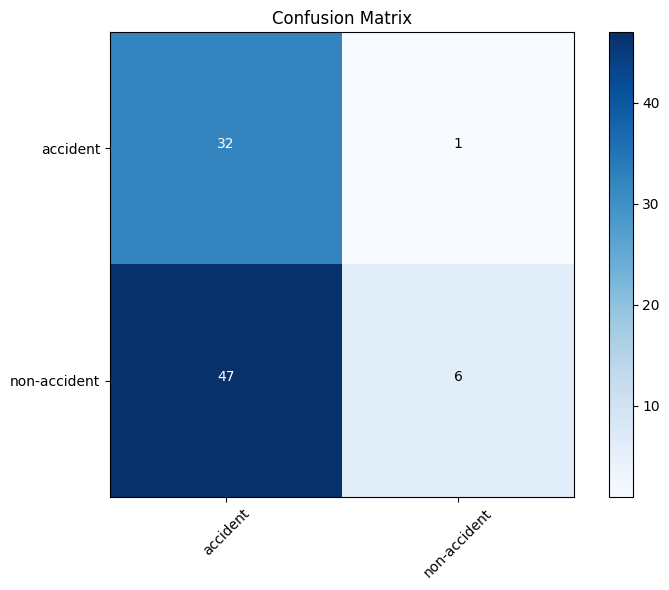

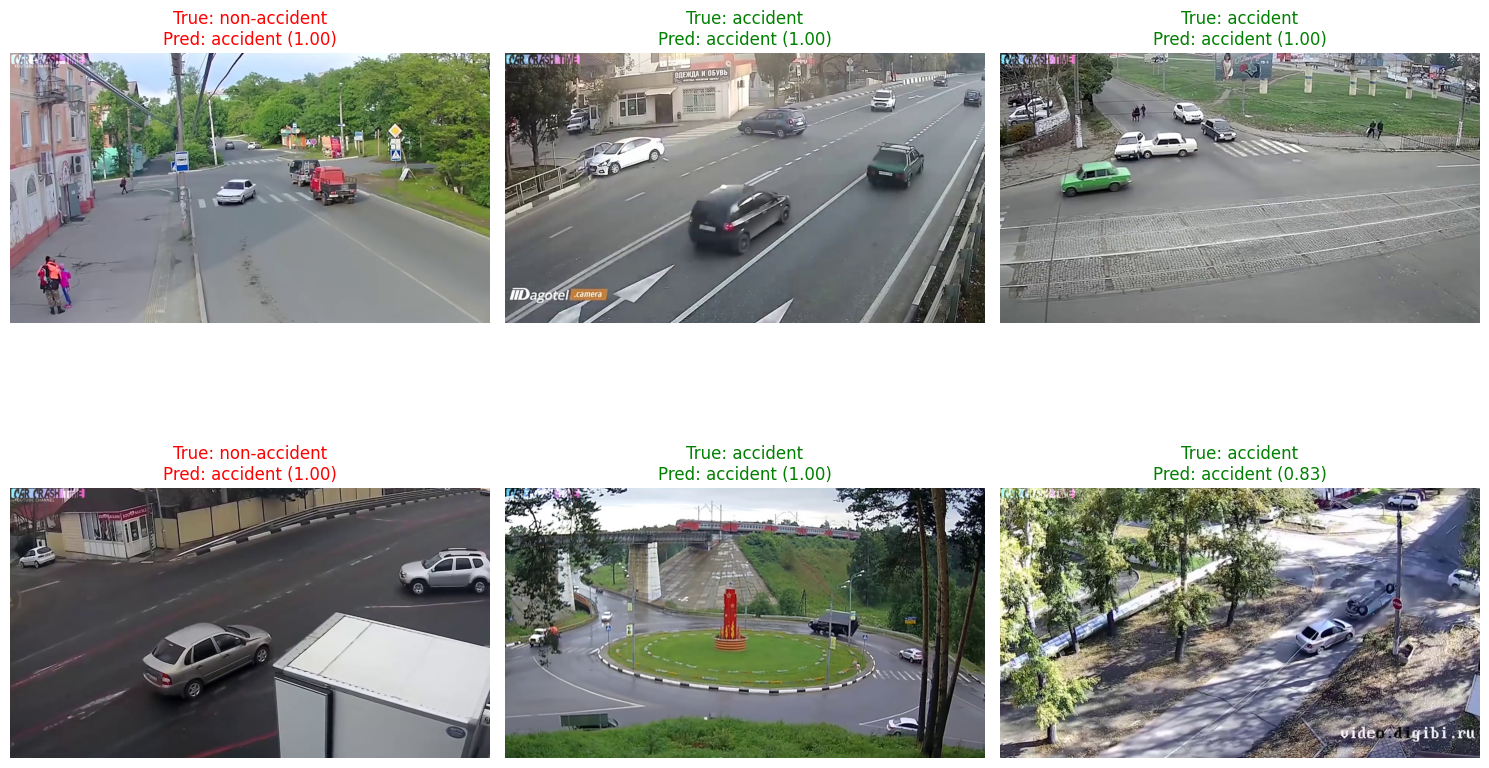


Total execution time: 176.47 seconds


In [ ]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image
import time
import glob
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Install required packages if not already installed
try:
    import ultralytics
except ModuleNotFoundError:
    print("Installing ultralytics package...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0', 'torchvision'])
    import ultralytics
    print("ultralytics installed successfully!")

from ultralytics import YOLO

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')

# Create necessary directories
os.makedirs(project_dir, exist_ok=True)

# Custom PyTorch Dataset class
class FoggyAccidentDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {'accident': 0, 'non-accident': 1}

        # Get all image paths and labels
        for class_name in ['accident', 'non-accident']:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Warning: {class_dir} does not exist")
                continue

            # Get all images in the class directory
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in glob.glob(os.path.join(class_dir, ext)):
                    self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Open and convert image
        try:
            image = Image.open(img_path).convert('RGB')

            # Apply transformations
            if self.transform:
                image = self.transform(image)

            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image and the same label if there's an error
            blank = torch.zeros(3, 224, 224) if self.transform else Image.new('RGB', (224, 224))
            return blank, label

# Function to train model using PyTorch directly
def train_model_pytorch():
    """Train a classification model using PyTorch directly instead of YOLOv8"""
    print("\nTraining using direct PyTorch implementation...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Define transformations
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create datasets
    train_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'train'),
        transform=train_transform
    )

    val_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'val'),
        transform=val_transform
    )

    test_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'test'),
        transform=val_transform
    )

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Load a pre-trained model
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)  # 2 classes: accident, non-accident
    model = model.to(device)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=3, verbose=True
    )

    # Training variables
    num_epochs = 20
    best_acc = 0.0
    best_model_path = os.path.join(project_dir, 'best_model.pth')

    # Training loop
    print("Starting training...")
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = accuracy_score(train_labels, train_preds)

        # Validation phase
        model.eval()
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                # Statistics
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        # Print statistics
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        # Update learning rate
        scheduler.step(val_acc)

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model with validation accuracy: {best_acc:.4f}")

    print(f"Training complete. Best validation accuracy: {best_acc:.4f}")

    # Load best model for evaluation
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    # Evaluate on test set
    test_preds = []
    test_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Statistics
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    test_acc = accuracy_score(test_labels, test_preds)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    cm = confusion_matrix(test_labels, test_preds)

    # Print test results
    print("\nTest Results:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['accident', 'non-accident'], rotation=45)
    plt.yticks(tick_marks, ['accident', 'non-accident'])

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "confusion_matrix_pytorch.png"), dpi=300)

    return best_model_path, {
        'accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': cm
    }

# Function to visualize predictions from PyTorch model
def visualize_pytorch_predictions(model_path, num_samples=6):
    """Visualize predictions from the PyTorch model"""
    print("\nVisualizing predictions from PyTorch model...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define transformations
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load model
    model = models.resnet18(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval()

    # Get test images
    test_dir = os.path.join(data_dir, 'test')
    test_images = []
    class_names = ['accident', 'non-accident']

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if not os.path.exists(class_dir):
            continue

        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in glob.glob(os.path.join(class_dir, ext)):
                test_images.append((img_path, idx))

    # Select random samples
    selected_samples = random.sample(test_images, min(num_samples, len(test_images)))

    # Create figure for visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    # Process each sample
    for i, (img_path, true_label) in enumerate(selected_samples):
        if i >= num_samples:
            break

        # Read and process image
        image = Image.open(img_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        # Get prediction
        with torch.no_grad():
            outputs = model(image_tensor)
            _, preds = torch.max(outputs, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_label = preds.item()
            confidence = probs[0][pred_label].item()

        # Display image
        axes[i].imshow(image)

        # Set title
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})"
        axes[i].set_title(title, color="green" if pred_label == true_label else "red")
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "prediction_visualization_pytorch.png"), dpi=300)
    plt.show()

# Main execution function
if __name__ == "__main__":
    start_time = time.time()
    print("\nFoggy Accident Detection System")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train model using PyTorch directly
        print("\nTraining model for accident detection...")
        best_model_path, results = train_model_pytorch()

        # Visualize predictions
        print("\nVisualizing predictions on test images...")
        visualize_pytorch_predictions(best_model_path)

        # Print total execution time
        total_time = time.time() - start_time
        print(f"\nTotal execution time: {total_time:.2f} seconds")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

Running in Google Colab
Setting up Google Drive...
Mounted at /content/drive

Foggy Accident Detection System
Using GPU: Tesla T4
GPU memory allocated: 16.25 MB
GPU memory reserved: 1196.00 MB

Training model for accident detection...

Training using direct PyTorch implementation...
Using device: cuda
Found 432 images in /content/drive/MyDrive/foggy_accident_detection/data/train
Found 98 images in /content/drive/MyDrive/foggy_accident_detection/data/val
Found 86 images in /content/drive/MyDrive/foggy_accident_detection/data/test
Class distribution in training set: Counter({0: 355, 1: 77})
Class weights: tensor([0.6085, 2.8052], device='cuda:0')
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/20 - Train Loss: 0.4611, Train Acc: 0.7847, Val Acc: 0.5306, Val Precision: 1.0000, Val Recall: 0.1154, Val F1: 0.2069
Saved new best model with validation accuracy: 0.5306
Saved new best model with validation F1 score: 0.2069
Epoch 2/20 - Train Loss: 0.2773, Train Acc: 0.9051, Val Acc: 0.5102, Val Precision: 1.0000, Val Recall: 0.0769, Val F1: 0.1429
Epoch 3/20 - Train Loss: 0.2471, Train Acc: 0.9074, Val Acc: 0.5408, Val Precision: 1.0000, Val Recall: 0.1346, Val F1: 0.2373
Saved new best model with validation accuracy: 0.5408
Saved new best model with validation F1 score: 0.2373
Epoch 4/20 - Train Loss: 0.1902, Train Acc: 0.9190, Val Acc: 0.6020, Val Precision: 0.6585, Val Recall: 0.5192, Val F1: 0.5806
Saved new best model with validation accuracy: 0.6020
Saved new best model with validation F1 score: 0.5806
Epoch 5/20 - Train Loss: 0.1474, Train Acc: 0.9236, Val Acc: 0.5408, Val Precision: 1.0000, Val Recall: 0.1346, Val F1: 0.2373
Epoch 6/20 - Train Loss: 0.1694, Train Ac

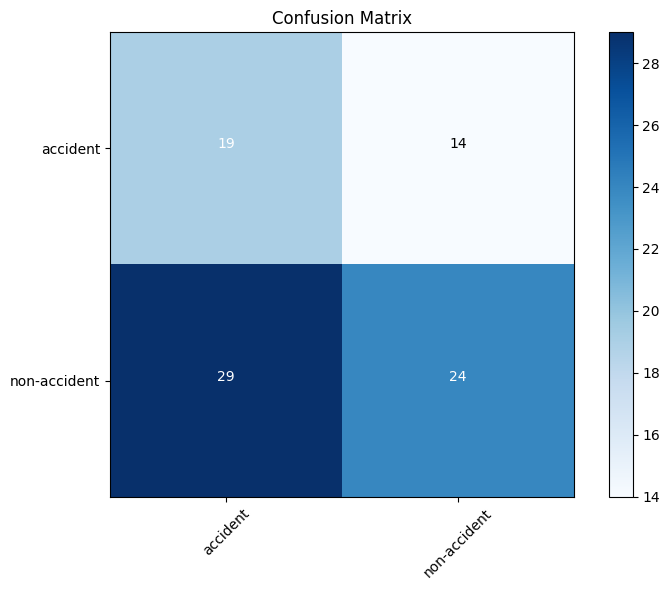

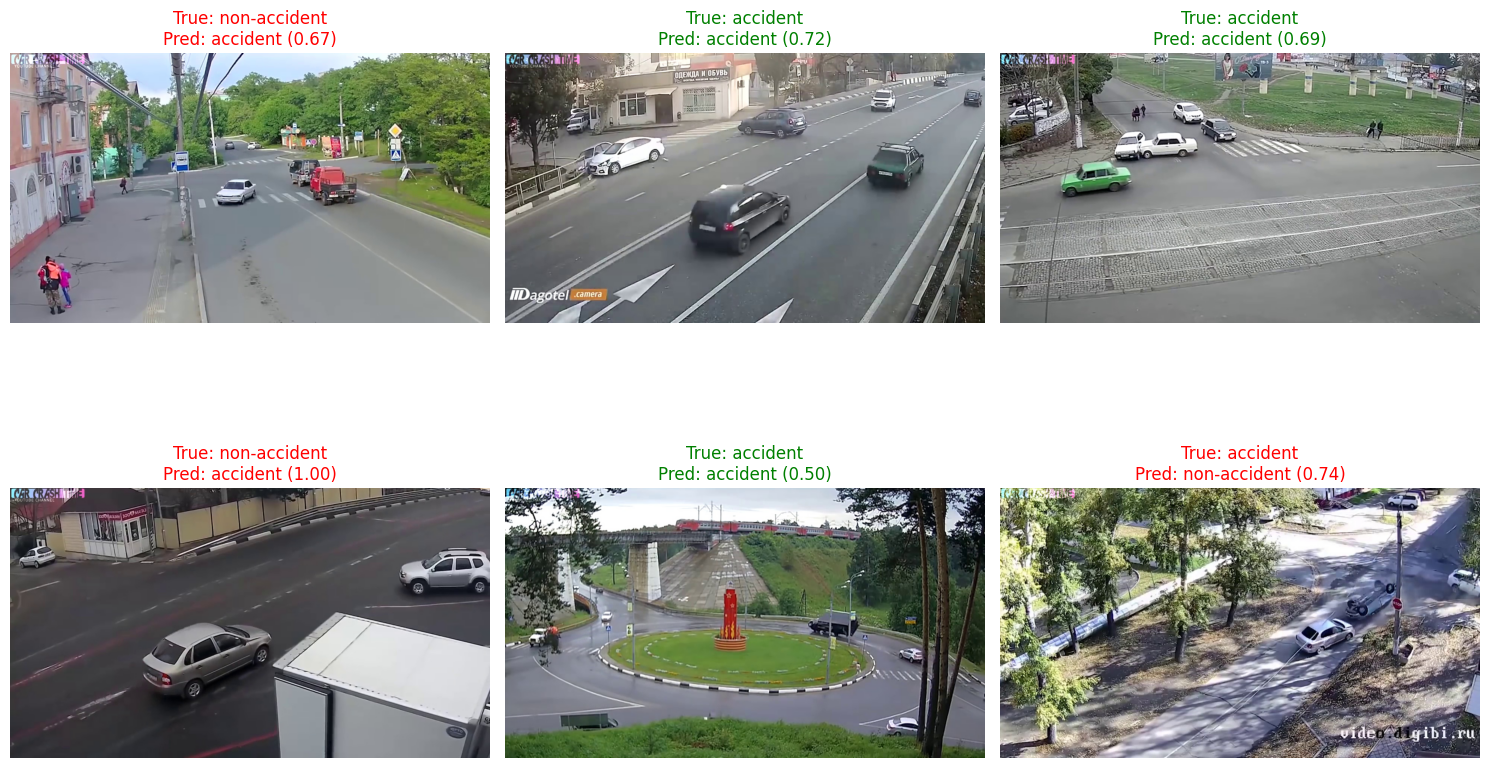


Total execution time: 177.58 seconds


In [ ]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image
import time
import glob
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter

# Install required packages if not already installed
try:
    import ultralytics
except ModuleNotFoundError:
    print("Installing ultralytics package...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0', 'torchvision'])
    import ultralytics
    print("ultralytics installed successfully!")

from ultralytics import YOLO

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')

# Create necessary directories
os.makedirs(project_dir, exist_ok=True)

# Custom PyTorch Dataset class
class FoggyAccidentDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {'accident': 0, 'non-accident': 1}

        # Get all image paths and labels
        for class_name in ['accident', 'non-accident']:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Warning: {class_dir} does not exist")
                continue

            # Get all images in the class directory
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in glob.glob(os.path.join(class_dir, ext)):
                    self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Open and convert image
        try:
            image = Image.open(img_path).convert('RGB')

            # Apply transformations
            if self.transform:
                image = self.transform(image)

            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image and the same label if there's an error
            blank = torch.zeros(3, 224, 224) if self.transform else Image.new('RGB', (224, 224))
            return blank, label

# Function to train model using PyTorch directly
def train_model_pytorch():
    """Train a classification model using PyTorch directly instead of YOLOv8"""
    print("\nTraining using direct PyTorch implementation...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Define transformations
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create datasets
    train_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'train'),
        transform=train_transform
    )

    val_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'val'),
        transform=val_transform
    )

    test_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'test'),
        transform=val_transform
    )

    # Calculate class weights to handle imbalance
    train_labels = [label for _, label in train_dataset.samples]
    label_counts = Counter(train_labels)
    print(f"Class distribution in training set: {label_counts}")

    # Calculate weights inversely proportional to class frequencies
    n_samples = len(train_labels)
    n_classes = len(label_counts)
    class_weights = [n_samples / (n_classes * count) for count in label_counts.values()]
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Class weights: {class_weights}")

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Load a pre-trained model
    model = models.resnet18(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)  # 2 classes: accident, non-accident
    model = model.to(device)

    # Define loss function with class weights and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=3, verbose=True
    )

    # Training variables
    num_epochs = 20
    best_acc = 0.0
    best_f1 = 0.0  # We'll now track F1 score as well
    best_model_path = os.path.join(project_dir, 'best_model.pth')
    best_f1_model_path = os.path.join(project_dir, 'best_f1_model.pth')

    # Training loop
    print("Starting training...")
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = accuracy_score(train_labels, train_preds)

        # Validation phase
        model.eval()
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                # Statistics
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        # Print statistics
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        # Update learning rate
        scheduler.step(val_f1)  # Now we're optimizing for F1 score

        # Save best model based on accuracy
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model with validation accuracy: {best_acc:.4f}")

        # Save best model based on F1 score
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_f1_model_path)
            print(f"Saved new best model with validation F1 score: {best_f1:.4f}")

    print(f"Training complete. Best validation accuracy: {best_acc:.4f}, Best F1 score: {best_f1:.4f}")

    # Use the model with the best F1 score for final evaluation (better for imbalanced datasets)
    model.load_state_dict(torch.load(best_f1_model_path if best_f1 > 0 else best_model_path))
    model.eval()

    # Evaluate on test set
    test_preds = []
    test_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # Statistics
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    test_acc = accuracy_score(test_labels, test_preds)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    cm = confusion_matrix(test_labels, test_preds)

    # Print test results
    print("\nTest Results:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['accident', 'non-accident'], rotation=45)
    plt.yticks(tick_marks, ['accident', 'non-accident'])

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "confusion_matrix_pytorch.png"), dpi=300)

    # Return both model paths and results
    return best_f1_model_path if best_f1 > 0 else best_model_path, {
        'accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': cm
    }

# Function to visualize predictions from PyTorch model
def visualize_pytorch_predictions(model_path, num_samples=6):
    """Visualize predictions from the PyTorch model"""
    print("\nVisualizing predictions from PyTorch model...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define transformations
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Load model
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval()

    # Get test images
    test_dir = os.path.join(data_dir, 'test')
    test_images = []
    class_names = ['accident', 'non-accident']

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if not os.path.exists(class_dir):
            continue

        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in glob.glob(os.path.join(class_dir, ext)):
                test_images.append((img_path, idx))

    # Select random samples
    selected_samples = random.sample(test_images, min(num_samples, len(test_images)))

    # Create figure for visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    # Process each sample
    for i, (img_path, true_label) in enumerate(selected_samples):
        if i >= num_samples:
            break

        # Read and process image
        image = Image.open(img_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        # Get prediction
        with torch.no_grad():
            outputs = model(image_tensor)
            _, preds = torch.max(outputs, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_label = preds.item()
            confidence = probs[0][pred_label].item()

        # Display image
        axes[i].imshow(image)

        # Set title
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})"
        axes[i].set_title(title, color="green" if pred_label == true_label else "red")
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "prediction_visualization_pytorch.png"), dpi=300)
    plt.show()

# Main execution function
if __name__ == "__main__":
    start_time = time.time()
    print("\nFoggy Accident Detection System")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train model using PyTorch directly
        print("\nTraining model for accident detection...")
        best_model_path, results = train_model_pytorch()

        # Visualize predictions
        print("\nVisualizing predictions on test images...")
        visualize_pytorch_predictions(best_model_path)

        # Print total execution time
        total_time = time.time() - start_time
        print(f"\nTotal execution time: {total_time:.2f} seconds")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

Running in Google Colab
Setting up Google Drive...
Mounted at /content/drive

Foggy Accident Detection System
Using GPU: Tesla T4
GPU memory allocated: 0.00 MB
GPU memory reserved: 0.00 MB

Training model for accident detection...

Training using direct PyTorch implementation...
Using device: cuda
Found 432 images in /content/drive/MyDrive/foggy_accident_detection/data/train
Found 98 images in /content/drive/MyDrive/foggy_accident_detection/data/val
Found 86 images in /content/drive/MyDrive/foggy_accident_detection/data/test
Class distribution in training set: Counter({0: 355, 1: 77})


<ipython-input-1-89faf548370f>:178: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.5, p=0.5),
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-1-89faf548370f>:190: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.4),
<ipython-input-1-89faf548370f>:191: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.4),


Class weights: tensor([0.7301, 2.8052], device='cuda:0')
Starting training...
Epoch 1/30 - LR: 0.000500 - Train Loss: 0.1339, Train Acc: 0.7448, Val Acc: 0.5204, Val Precision: 0.8571, Val Recall: 0.1154, Val F1: 0.2034
Saved new best model with validation accuracy: 0.5204
Saved new best model with validation F1 score: 0.2034
Epoch 2/30 - LR: 0.000500 - Train Loss: 0.0955, Train Acc: 0.8750, Val Acc: 0.5204, Val Precision: 0.8571, Val Recall: 0.1154, Val F1: 0.2034
Epoch 3/30 - LR: 0.000450 - Train Loss: 0.0985, Train Acc: 0.8884, Val Acc: 0.5306, Val Precision: 0.8750, Val Recall: 0.1346, Val F1: 0.2333
Saved new best model with validation accuracy: 0.5306
Saved new best model with validation F1 score: 0.2333
Epoch 4/30 - LR: 0.000405 - Train Loss: 0.0695, Train Acc: 0.8884, Val Acc: 0.5510, Val Precision: 1.0000, Val Recall: 0.1538, Val F1: 0.2667
Saved new best model with validation accuracy: 0.5510
Saved new best model with validation F1 score: 0.2667
Epoch 5/30 - LR: 0.000365 - Tr

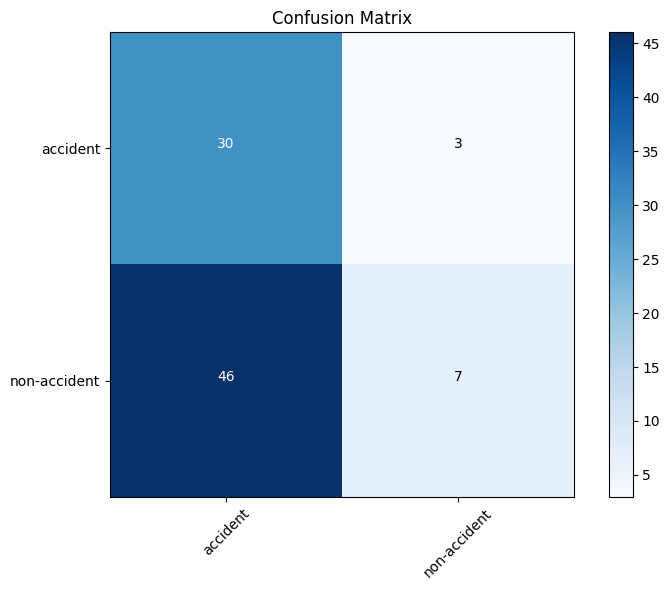

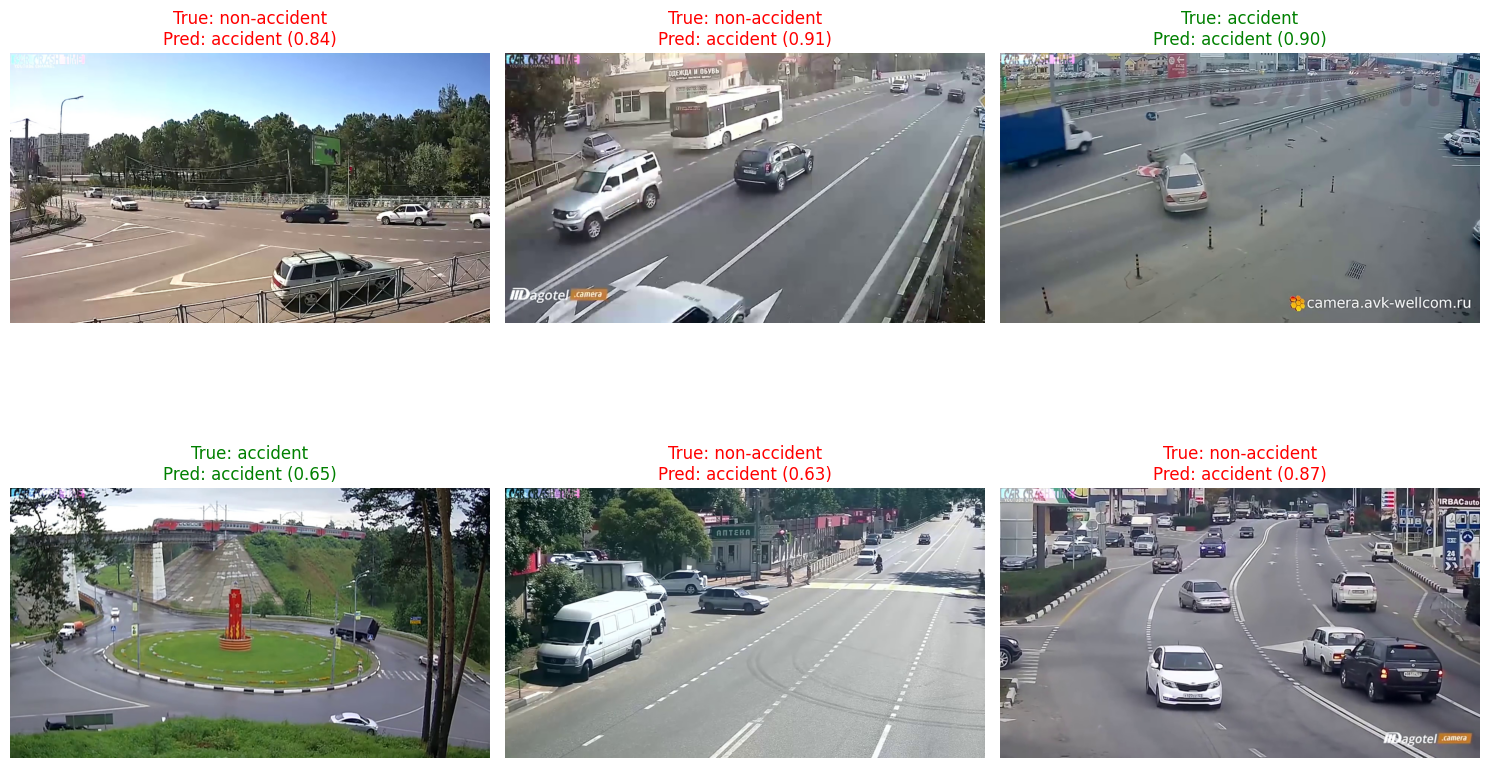


Total execution time: 543.84 seconds


In [ ]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image
import time
import glob
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Install required packages if not already installed
try:
    import ultralytics
    import albumentations
except ModuleNotFoundError:
    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0', 'torchvision', 'albumentations'])
    import ultralytics
    import albumentations
    print("Packages installed successfully!")

from ultralytics import YOLO

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')

# Create necessary directories
os.makedirs(project_dir, exist_ok=True)

# Focal Loss implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Mixup augmentation
def mixup_data(x, y, alpha=0.2):
    """Applies mixup augmentation to the batch"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculates loss with mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Custom PyTorch Dataset class with Albumentations support
class FoggyAccidentDataset(Dataset):
    def __init__(self, root_dir, transform=None, augmentations=None):
        self.root_dir = root_dir
        self.transform = transform  # PyTorch transforms
        self.augmentations = augmentations  # Albumentations transforms
        self.samples = []
        self.class_to_idx = {'accident': 0, 'non-accident': 1}

        # Get all image paths and labels
        for class_name in ['accident', 'non-accident']:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Warning: {class_dir} does not exist")
                continue

            # Get all images in the class directory
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in glob.glob(os.path.join(class_dir, ext)):
                    self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Open and convert image
        try:
            # Using OpenCV for better compatibility with Albumentations
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Apply Albumentations augmentations first if available
            if self.augmentations:
                augmented = self.augmentations(image=image)
                image = augmented['image']

            # Apply PyTorch transformations if available
            if self.transform:
                image = self.transform(image)

            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image and the same label if there's an error
            blank = torch.zeros(3, 224, 224) if self.transform else np.zeros((224, 224, 3), dtype=np.uint8)
            return blank, label

# Function to train model using PyTorch directly
def train_model_pytorch():
    """Train a classification model using PyTorch directly instead of YOLOv8"""
    print("\nTraining using direct PyTorch implementation...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Define advanced augmentations with Albumentations for training
    train_augs = A.Compose([
        A.Resize(224, 224),
        A.OneOf([
            A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.5, p=0.5),
            A.RandomRain(p=0.5),
            A.RandomSnow(p=0.5),
        ], p=0.7),
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.HueSaturationValue(p=0.8),
        ], p=0.8),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
        A.GaussNoise(var_limit=(10, 50), p=0.4),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.4),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Validation transforms - just resize, normalize and convert to tensor
    val_augs = A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Create datasets
    train_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'train'),
        augmentations=train_augs
    )

    val_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'val'),
        augmentations=val_augs
    )

    test_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'test'),
        augmentations=val_augs
    )

    # Calculate class weights to handle imbalance
    train_labels = [label for _, label in train_dataset.samples]
    label_counts = Counter(train_labels)
    print(f"Class distribution in training set: {label_counts}")

    # Calculate weights inversely proportional to class frequencies with additional emphasis
    n_samples = len(train_labels)
    n_classes = len(label_counts)
    class_weights = [n_samples / (n_classes * count) for count in label_counts.values()]

    # Boost the weight for the accident class (assuming it's index 0) by 20%
    if 0 in label_counts:
        class_weights[0] *= 1.2

    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Class weights: {class_weights}")

    # Create data loaders with different batch sizes for better gradient estimation
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,  # Smaller batch size for more updates
        shuffle=True,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Load a pre-trained model - using a more powerful backbone
    model = models.efficientnet_b2(weights='IMAGENET1K_V1')

    # Replace classifier head
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),  # Add dropout for regularization
        nn.Linear(num_ftrs, 2)  # 2 classes: accident, non-accident
    )
    model = model.to(device)

    # Define loss function with class weights and optimizer
    criterion = FocalLoss(gamma=2.0)  # Use Focal Loss for imbalanced data
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)  # Use AdamW with weight decay

    # Learning rate scheduler with initial warmup
    def lr_lambda(epoch):
        if epoch < 2:  # Warm up for 2 epochs
            return 0.5 * (epoch + 1)  # Linear warmup from 0.5x to 1x
        else:
            return 1.0 * (0.9 ** (epoch - 2))  # Then decay by 10% each epoch

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    # Training variables
    num_epochs = 30  # Train for more epochs
    best_acc = 0.0
    best_f1 = 0.0
    best_model_path = os.path.join(project_dir, 'best_model.pth')
    best_f1_model_path = os.path.join(project_dir, 'best_f1_model.pth')

    # Training loop
    print("Starting training...")
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Apply mixup augmentation 50% of the time
            if random.random() < 0.5:
                inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2)
                use_mixup = True
            else:
                use_mixup = False

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Calculate loss with or without mixup
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            if not use_mixup:  # Only track accuracy for non-mixup batches
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = accuracy_score(train_labels, train_preds) if train_preds else 0

        # Validation phase
        model.eval()
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                # Statistics
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        # Update learning rate
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        # Print statistics
        print(f"Epoch {epoch+1}/{num_epochs} - LR: {current_lr:.6f} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        # Save best model based on accuracy
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model with validation accuracy: {best_acc:.4f}")

        # Save best model based on F1 score
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_f1_model_path)
            print(f"Saved new best model with validation F1 score: {best_f1:.4f}")

    print(f"Training complete. Best validation accuracy: {best_acc:.4f}, Best F1 score: {best_f1:.4f}")

    # Use the model with the best F1 score for final evaluation (better for imbalanced datasets)
    model.load_state_dict(torch.load(best_f1_model_path if best_f1 > 0 else best_model_path))
    model.eval()

    # Test time augmentation: run multiple augmentations on each test image
    def test_time_augmentation(model, image, device, num_augs=5):
        # Define TTA transforms
        tta_transforms = [
            A.Compose([
                A.Resize(224, 224),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(224, 224),
                A.HorizontalFlip(p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(240, 240),
                A.CenterCrop(224, 224),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(224, 224),
                A.RandomBrightnessContrast(p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(224, 224),
                A.GaussianBlur(blur_limit=(3, 3), p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])
        ]

        # Run model with multiple augmentations
        all_outputs = []

        for transform in tta_transforms[:num_augs]:
            augmented = transform(image=image)
            input_tensor = augmented['image'].unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                all_outputs.append(output)

        # Average predictions
        avg_output = torch.mean(torch.stack(all_outputs), dim=0)
        _, pred = torch.max(avg_output, 1)

        return pred.item(), avg_output

    # Evaluate with test-time augmentation
    test_preds = []
    test_labels = []
    test_tta_enabled = True  # Set to False to disable TTA

    for idx, (inputs, labels) in enumerate(test_loader):
        batch_labels = labels.cpu().numpy()
        test_labels.extend(batch_labels)

        if test_tta_enabled:
            # For TTA we need to process each image individually
            batch_preds = []
            for i in range(inputs.shape[0]):
                # Convert tensor back to numpy for albumentations
                if isinstance(inputs, torch.Tensor):
                    # Denormalize and convert to numpy
                    img = inputs[i].cpu().numpy().transpose(1, 2, 0)
                    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                    img = (img * 255).astype(np.uint8)
                else:
                    img = inputs[i]

                pred, _ = test_time_augmentation(model, img, device)
                batch_preds.append(pred)

            test_preds.extend(batch_preds)
        else:
            # Standard evaluation without TTA
            inputs = inputs.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                test_preds.extend(preds.cpu().numpy())

    # Calculate metrics
    test_acc = accuracy_score(test_labels, test_preds)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    cm = confusion_matrix(test_labels, test_preds)

    # Print test results
    print("\nTest Results:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['accident', 'non-accident'], rotation=45)
    plt.yticks(tick_marks, ['accident', 'non-accident'])

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "confusion_matrix_pytorch.png"), dpi=300)

    # Return both model paths and results
    return best_f1_model_path if best_f1 > 0 else best_model_path, {
        'accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': cm
    }

# Function to visualize predictions from PyTorch model
def visualize_pytorch_predictions(model_path, num_samples=6):
    """Visualize predictions from the PyTorch model"""
    print("\nVisualizing predictions from PyTorch model...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define transformations using Albumentations
    transform = A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Load model
    model = models.efficientnet_b2(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(num_ftrs, 2)
    )
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval()

    # Get test images
    test_dir = os.path.join(data_dir, 'test')
    test_images = []
    class_names = ['accident', 'non-accident']

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if not os.path.exists(class_dir):
            continue

        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in glob.glob(os.path.join(class_dir, ext)):
                test_images.append((img_path, idx))

    # Select random samples
    selected_samples = random.sample(test_images, min(num_samples, len(test_images)))

    # Create figure for visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    # Process each sample
    for i, (img_path, true_label) in enumerate(selected_samples):
        if i >= num_samples:
            break

        # Read and process image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transformation
        transformed = transform(image=image)
        image_tensor = transformed['image'].unsqueeze(0).to(device)

        # Get prediction
        with torch.no_grad():
            outputs = model(image_tensor)
            _, preds = torch.max(outputs, 1)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_label = preds.item()
            confidence = probs[0][pred_label].item()

        # Display image
        axes[i].imshow(image)

        # Set title
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})"
        axes[i].set_title(title, color="green" if pred_label == true_label else "red")
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "prediction_visualization_pytorch.png"), dpi=300)
    plt.show()

# Main execution function
if __name__ == "__main__":
    start_time = time.time()
    print("\nFoggy Accident Detection System")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train model using PyTorch directly
        print("\nTraining model for accident detection...")
        best_model_path, results = train_model_pytorch()

        # Visualize predictions
        print("\nVisualizing predictions on test images...")
        visualize_pytorch_predictions(best_model_path)

        # Print total execution time
        total_time = time.time() - start_time
        print(f"\nTotal execution time: {total_time:.2f} seconds")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

In [ ]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image
import time
import glob
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Install required packages if not already installed
try:
    import ultralytics
    import albumentations
except ModuleNotFoundError:
    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0', 'torchvision', 'albumentations'])
    import ultralytics
    import albumentations
    print("Packages installed successfully!")

from ultralytics import YOLO

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')

# Create necessary directories
os.makedirs(project_dir, exist_ok=True)

# Focal Loss implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Mixup augmentation
def mixup_data(x, y, alpha=0.2):
    """Applies mixup augmentation to the batch"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculates loss with mixup"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Custom PyTorch Dataset class with Albumentations support
class FoggyAccidentDataset(Dataset):
    def __init__(self, root_dir, transform=None, augmentations=None):
        self.root_dir = root_dir
        self.transform = transform  # PyTorch transforms
        self.augmentations = augmentations  # Albumentations transforms
        self.samples = []
        self.class_to_idx = {'accident': 0, 'non-accident': 1}

        # Get all image paths and labels
        for class_name in ['accident', 'non-accident']:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Warning: {class_dir} does not exist")
                continue

            # Get all images in the class directory
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in glob.glob(os.path.join(class_dir, ext)):
                    self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Open and convert image
        try:
            # Using OpenCV for better compatibility with Albumentations
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Apply Albumentations augmentations first if available
            if self.augmentations:
                augmented = self.augmentations(image=image)
                image = augmented['image']

            # Apply PyTorch transformations if available
            if self.transform:
                image = self.transform(image)

            return image, label
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a blank image and the same label if there's an error
            blank = torch.zeros(3, 224, 224) if self.transform else np.zeros((224, 224, 3), dtype=np.uint8)
            return blank, label

# Function to train model using PyTorch directly
def train_model_pytorch():
    """Train a classification model using PyTorch directly instead of YOLOv8"""
    print("\nTraining using direct PyTorch implementation...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Define advanced augmentations with Albumentations for training
    train_augs = A.Compose([
        A.Resize(224, 224),
        A.OneOf([
            A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.5, p=0.5),
            A.RandomRain(p=0.5),
            A.RandomSnow(p=0.5),
        ], p=0.7),
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.HueSaturationValue(p=0.8),
        ], p=0.8),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
        A.GaussNoise(var_limit=(10, 50), p=0.4),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.4),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Validation transforms - just resize, normalize and convert to tensor
    val_augs = A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Create datasets
    train_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'train'),
        augmentations=train_augs
    )

    val_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'val'),
        augmentations=val_augs
    )

    test_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'test'),
        augmentations=val_augs
    )

    # Calculate class weights to handle imbalance
    train_labels = [label for _, label in train_dataset.samples]
    label_counts = Counter(train_labels)
    print(f"Class distribution in training set: {label_counts}")

    # Calculate weights inversely proportional to class frequencies with additional emphasis
    n_samples = len(train_labels)
    n_classes = len(label_counts)
    class_weights = [n_samples / (n_classes * count) for count in label_counts.values()]

    # Adjust weights to better balance precision and recall
    # We're getting too many false positives, so we'll reduce the weight for accident class
    if 0 in label_counts:
        class_weights[0] *= 0.9  # Reduce accident weight slightly
    if 1 in label_counts:
        class_weights[1] *= 1.1  # Increase non-accident weight slightly

    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Class weights: {class_weights}")

    # Create data loaders with different batch sizes for better gradient estimation
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,  # Smaller batch size for more updates
        shuffle=True,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Load a pre-trained model - using a more complex model
    model = models.efficientnet_b4(weights='IMAGENET1K_V1')

    # Replace classifier head
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),  # Increase dropout for more regularization
        nn.Linear(num_ftrs, 2)  # 2 classes: accident, non-accident
    )
    model = model.to(device)

    # Define loss function with class weights and optimizer
    # gamma=1.5 instead of 2.0 - less aggressive focus on hard examples
    criterion = FocalLoss(gamma=1.5)
    optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=3e-4)  # Increased weight decay

    # Learning rate scheduler with initial warmup and ReduceLROnPlateau
    def lr_lambda(epoch):
        if epoch < 3:  # Warm up for 3 epochs
            return 0.5 * (epoch + 1)  # Linear warmup from 0.5x to 1x
        else:
            return 1.0 * (0.9 ** (epoch - 3))  # Then decay by 10% each epoch

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    reduce_lr_on_plateau = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)

    # Training variables
    num_epochs = 50  # Train for more epochs
    best_acc = 0.0
    best_f1 = 0.0
    best_model_path = os.path.join(project_dir, 'best_model.pth')
    best_f1_model_path = os.path.join(project_dir, 'best_f1_model.pth')

    # Store validation probabilities and labels for threshold tuning
    all_val_probs = []
    all_val_labels = []

    # Early stopping parameters
    early_stopping_patience = 10
    early_stopping_counter = 0

    # Training loop
    print("Starting training...")
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Apply mixup augmentation 50% of the time
            if random.random() < 0.5:
                inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2)
                use_mixup = True
            else:
                use_mixup = False

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Calculate loss with or without mixup
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            if not use_mixup:  # Only track accuracy for non-mixup batches
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = accuracy_score(train_labels, train_preds) if train_preds else 0

        # Validation phase
        model.eval()
        val_preds = []
        val_labels = []
        val_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                outputs = model(inputs)
                # Get probabilities
                probs = torch.nn.functional.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                # Statistics
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())

        # Store for threshold tuning
        all_val_probs.extend(val_probs)
        all_val_labels.extend(val_labels)

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        # Update learning rate
        scheduler.step()
        reduce_lr_on_plateau.step(val_f1)
        current_lr = scheduler.get_last_lr()[0]

        # Print statistics
        print(f"Epoch {epoch+1}/{num_epochs} - LR: {current_lr:.6f} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        # Save best model based on accuracy
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model with validation accuracy: {best_acc:.4f}")
            early_stopping_counter = 0  # Reset early stopping counter

        # Save best model based on F1 score
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_f1_model_path)
            print(f"Saved new best model with validation F1 score: {best_f1:.4f}")
            early_stopping_counter = 0  # Reset early stopping counter
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_patience:
                print("Early stopping triggered.")
                break

    print(f"Training complete. Best validation accuracy: {best_acc:.4f}, Best F1 score: {best_f1:.4f}")

    # Find optimal decision threshold
    if all_val_probs:
        all_val_probs = np.array(all_val_probs)
        all_val_labels = np.array(all_val_labels)

        # Convert probabilities to numpy array if not already
        if isinstance(all_val_probs, list):
            all_val_probs = np.array(all_val_probs)

        # Get probabilities for the accident class (index 0)
        accident_probs = all_val_probs[:, 0]

        # Try different thresholds to find optimal F1 score
        best_threshold = 0.5
        best_f1 = 0.0
        best_precision = 0.0
        best_recall = 0.0

        thresholds = np.arange(0.1, 0.9, 0.05)
        threshold_results = []

        for threshold in thresholds:
            # Predict accident if probability exceeds threshold
            val_preds_thresh = (accident_probs >= threshold).astype(int)
            # Convert to actual class indices (0=accident, 1=non-accident)
            val_preds_thresh = 1 - val_preds_thresh

            # Calculate metrics
            precision = precision_score(all_val_labels, val_preds_thresh, zero_division=0)
            recall = recall_score(all_val_labels, val_preds_thresh, zero_division=0)
            f1 = f1_score(all_val_labels, val_preds_thresh, zero_division=0)

            threshold_results.append((threshold, precision, recall, f1))

            # We want good balance between precision and recall
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
                best_precision = precision
                best_recall = recall

        print(f"\nOptimal threshold: {best_threshold:.2f}")
        print(f"At optimal threshold - Precision: {best_precision:.4f}, Recall: {best_recall:.4f}, F1: {best_f1:.4f}")

        # Plot precision-recall curve for different thresholds
        plt.figure(figsize=(10, 6))
        thresholds_arr = np.array([t[0] for t in threshold_results])
        precision_arr = np.array([t[1] for t in threshold_results])
        recall_arr = np.array([t[2] for t in threshold_results])
        f1_arr = np.array([t[3] for t in threshold_results])

        plt.plot(thresholds_arr, precision_arr, 'b-', label='Precision')
        plt.plot(thresholds_arr, recall_arr, 'g-', label='Recall')
        plt.plot(thresholds_arr, f1_arr, 'r-', label='F1 Score')
        plt.axvline(x=best_threshold, color='k', linestyle='--', label=f'Optimal Threshold ({best_threshold:.2f})')
        plt.title('Precision, Recall and F1 Score vs Threshold')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(project_dir, "threshold_optimization.png"), dpi=300)
    else:
        best_threshold = 0.5

    # Use the model with the best F1 score for final evaluation
    model.load_state_dict(torch.load(best_f1_model_path if best_f1 > 0 else best_model_path))
    model.eval()

    # Test time augmentation: run multiple augmentations on each test image
    def test_time_augmentation(model, image, device, num_augs=5):
        # Define TTA transforms
        tta_transforms = [
            A.Compose([
                A.Resize(224, 224),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(224, 224),
                A.HorizontalFlip(p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(240, 240),
                A.CenterCrop(224, 224),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(224, 224),
                A.RandomBrightnessContrast(p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ]),
            A.Compose([
                A.Resize(224, 224),
                A.GaussianBlur(blur_limit=(3, 3), p=1.0),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2(),
            ])
        ]

        # Run model with multiple augmentations
        all_outputs = []

        for transform in tta_transforms[:num_augs]:
            augmented = transform(image=image)
            input_tensor = augmented['image'].unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                all_outputs.append(output)

        # Average predictions
        avg_output = torch.mean(torch.stack(all_outputs), dim=0)
        probs = torch.nn.functional.softmax(avg_output, dim=1)

        # Apply custom threshold for accident class
        accident_prob = probs[0][0].item()
        pred = 0 if accident_prob >= best_threshold else 1

        return pred, probs[0]

    # Evaluate with test-time augmentation
    test_preds = []
    test_labels = []
    test_probs = []
    test_tta_enabled = True  # Set to False to disable TTA

    for idx, (inputs, labels) in enumerate(test_loader):
        batch_labels = labels.cpu().numpy()
        test_labels.extend(batch_labels)

        if test_tta_enabled:
            # For TTA we need to process each image individually
            batch_preds = []
            batch_probs = []

            for i in range(inputs.shape[0]):
                # Convert tensor back to numpy for albumentations
                if isinstance(inputs, torch.Tensor):
                    # Denormalize and convert to numpy
                    img = inputs[i].cpu().numpy().transpose(1, 2, 0)
                    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                    img = (img * 255).astype(np.uint8)
                else:
                    img = inputs[i]

                pred, probs = test_time_augmentation(model, img, device)
                batch_preds.append(pred)
                batch_probs.append(probs.cpu().numpy())

            test_preds.extend(batch_preds)
            test_probs.extend(batch_probs)
        else:
            # Standard evaluation without TTA
            inputs = inputs.to(device)
            with torch.no_grad():
                outputs = model(inputs)
                probs = torch.nn.functional.softmax(outputs, dim=1)

                # Apply custom threshold
                accident_probs = probs[:, 0].cpu().numpy()
                preds = np.where(accident_probs >= best_threshold, 0, 1)

                test_preds.extend(preds)
                test_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    test_acc = accuracy_score(test_labels, test_preds)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    cm = confusion_matrix(test_labels, test_preds)

    # Print test results
    print("\nTest Results with optimal threshold:")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {test_f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Plot confusion matrix with percentages and counts
    plt.figure(figsize=(10, 8))
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['accident', 'non-accident'], rotation=45)
    plt.yticks(tick_marks, ['accident', 'non-accident'])

    # Add text annotations with both count and percentage
    fmt = '.2f'
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                    fontsize=12)

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(os.path.join(project_dir, "confusion_matrix_pytorch.png"), dpi=300)

    # Generate ROC curve
    if test_probs:
        from sklearn.metrics import roc_curve, auc
        test_probs_arr = np.array(test_probs)
        # Get probability of the accident class (index 0)
        y_score = test_probs_arr[:, 0]

        # Convert test_labels to binary format (0=non-accident, 1=accident)
        y_true = np.array([1 - label for label in test_labels])

        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(project_dir, "roc_curve.png"), dpi=300)

    # Return both model paths, best threshold and results
    return best_f1_model_path if best_f1 > 0 else best_model_path, {
        'accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'confusion_matrix': cm,
        'threshold': best_threshold
    }

# Function to visualize predictions from PyTorch model
def visualize_pytorch_predictions(model_path, num_samples=6, threshold=0.5):
    """Visualize predictions from the PyTorch model"""
    print("\nVisualizing predictions from PyTorch model...")
    print(f"Using classification threshold: {threshold:.2f}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define transformations using Albumentations
    transform = A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Load model
    model = models.efficientnet_b4(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, 2)
    )
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    model.eval()

    # Get test images
    test_dir = os.path.join(data_dir, 'test')
    test_images = []
    class_names = ['accident', 'non-accident']

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if not os.path.exists(class_dir):
            continue

        for ext in ['*.jpg', '*.jpeg', '*.png']:
            for img_path in glob.glob(os.path.join(class_dir, ext)):
                test_images.append((img_path, idx))

    # Select random samples
    selected_samples = random.sample(test_images, min(num_samples, len(test_images)))

    # Create figure for visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    # Process each sample
    for i, (img_path, true_label) in enumerate(selected_samples):
        if i >= num_samples:
            break

        # Read and process image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transformation
        transformed = transform(image=image)
        image_tensor = transformed['image'].unsqueeze(0).to(device)

        # Get prediction
        with torch.no_grad():
            outputs = model(image_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)

            # Apply custom threshold
            accident_prob = probs[0][0].item()
            pred_label = 0 if accident_prob >= threshold else 1
            confidence = probs[0][pred_label].item()

        # Display image
        axes[i].imshow(image)

        # Set title with probability for accident class
        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nAccident prob: {accident_prob:.2f}"
        axes[i].set_title(title, color="green" if pred_label == true_label else "red")
        axes[i].axis("off")

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "prediction_visualization_pytorch.png"), dpi=300)
    plt.show()

# Main execution function
if __name__ == "__main__":
    start_time = time.time()
    print("\nFoggy Accident Detection System")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train model using PyTorch directly
        print("\nTraining model for accident detection...")
        best_model_path, results = train_model_pytorch()

        # Visualize predictions using the optimal threshold
        print("\nVisualizing predictions on test images...")
        threshold = results.get('threshold', 0.5)
        visualize_pytorch_predictions(best_model_path, threshold=threshold)

        # Print total execution time
        total_time = time.time() - start_time
        print(f"\nTotal execution time: {total_time:.2f} seconds")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

Running in Google Colab
Setting up Google Drive...
Mounted at /content/drive

Foggy Accident Detection System

Training model for accident detection...

Training using direct PyTorch implementation...
Using device: cpu
Found 0 images in /content/drive/MyDrive/foggy_accident_detection/data/train
Found 0 images in /content/drive/MyDrive/foggy_accident_detection/data/val
Found 0 images in /content/drive/MyDrive/foggy_accident_detection/data/test
Class distribution in training set: Counter()
Class weights: tensor([])
An error occurred: num_samples should be a positive integer value, but got num_samples=0


<ipython-input-7-4032c96b4386>:179: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.3, fog_coef_upper=0.5, p=0.5),
<ipython-input-7-4032c96b4386>:191: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.4),
<ipython-input-7-4032c96b4386>:192: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.4),
Traceback (most recent call last):
  File "<ipython-input-7-4032c96b4386>", line 766, in <cell line: 0>
    best_model_path, results = train_model_pytorch()
                               ^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-7-4032c96b4386>", line 241, in train_model_pytorch
    train_loader = DataLoader(
                   ^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 383, in __ini

In [11]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image
import time
import glob
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Install required packages if not already installed
try:
    import ultralytics
    import albumentations
except ModuleNotFoundError:
    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0', 'torchvision', 'albumentations'])
    import ultralytics
    import albumentations
    print("Packages installed successfully!")

from ultralytics import YOLO

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
    project_dir = os.path.join(base_dir, 'yolo_project')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')
project_dir = os.path.join(base_dir, 'yolo_project')

# Create necessary directories
os.makedirs(project_dir, exist_ok=True)

# Custom PyTorch Dataset class with Albumentations support
class FoggyAccidentDataset(Dataset):
    def __init__(self, root_dir, transform=None, augmentations=None):
        self.root_dir = root_dir
        self.transform = transform
        self.augmentations = augmentations
        self.samples = []
        self.class_to_idx = {'Accident': 0, 'Non Accident': 1}

        for class_name in ['Accident', 'Non Accident']:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Warning: {class_dir} does not exist")
                continue
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in glob.glob(os.path.join(class_dir, ext)):
                    self.samples.append((img_path, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} images in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.augmentations:
            augmented = self.augmentations(image=image)
            image = augmented['image']
        if self.transform:
            image = self.transform(image)
        return image, label

# Focal Loss implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# Function to train model using PyTorch directly
def train_model_pytorch(data_dir, project_dir):
    """Train a classification model using PyTorch directly"""
    print("\nTraining using direct PyTorch implementation...")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Define advanced augmentations with Albumentations for training
    train_augs = A.Compose([
        A.Resize(224, 224),
        A.OneOf([
            A.RandomFog(p=0.5),
            A.RandomRain(p=0.5),
            A.RandomSnow(p=0.5),
        ], p=0.7),
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.HueSaturationValue(p=0.8),
        ], p=0.8),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15, p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.GaussianBlur(blur_limit=(3, 7), p=0.4),
        A.GaussNoise(p=0.4),
        A.CoarseDropout(p=0.4),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Validation transforms - just resize, normalize and convert to tensor
    val_augs = A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Create datasets
    train_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'train'),
        augmentations=train_augs
    )

    val_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'val'),
        augmentations=val_augs
    )

    test_dataset = FoggyAccidentDataset(
        root_dir=os.path.join(data_dir, 'test'),
        augmentations=val_augs
    )

    # Calculate class weights to handle imbalance
    train_labels = [label for _, label in train_dataset.samples]
    label_counts = Counter(train_labels)
    print(f"Class distribution in training set: {label_counts}")

    # Calculate weights inversely proportional to class frequencies
    n_samples = len(train_labels)
    n_classes = len(label_counts)
    class_weights = [n_samples / (n_classes * count) for count in label_counts.values()]
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Class weights: {class_weights}")

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Load a pre-trained EfficientNet model
    model = models.efficientnet_b4(weights='IMAGENET1K_V1')

    # Replace classifier head
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, 2)
    )
    model = model.to(device)

    # Define loss function with class weights and optimizer
    criterion = FocalLoss(gamma=1.5)
    optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=3e-4)

    # Learning rate scheduler
    def lr_lambda(epoch):
        if epoch < 3:
            return 0.5 * (epoch + 1)
        else:
            return 1.0 * (0.9 ** (epoch - 3))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    reduce_lr_on_plateau = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)

    # Training variables
    num_epochs = 50
    best_acc = 0.0
    best_f1 = 0.0
    best_model_path = os.path.join(project_dir, 'best_model.pth')
    best_f1_model_path = os.path.join(project_dir, 'best_f1_model.pth')

    # Training loop
    print("Starting training...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = accuracy_score(train_labels, train_preds)

        # Validation phase
        model.eval()
        val_preds = []
        val_labels = []
        val_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                probs = torch.nn.functional.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        scheduler.step()
        reduce_lr_on_plateau.step(val_f1)
        current_lr = scheduler.get_last_lr()[0]

        print(f"Epoch {epoch+1}/{num_epochs} - LR: {current_lr:.6f} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
              f"Val Acc: {val_acc:.4f}, Val Precision: {val_precision:.4f}, "
              f"Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model with validation accuracy: {best_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_f1_model_path)
            print(f"Saved new best model with validation F1 score: {best_f1:.4f}")

    print(f"Training complete. Best validation accuracy: {best_acc:.4f}, Best F1 score: {best_f1:.4f}")

# Main execution function
if __name__ == "__main__":
    start_time = time.time()
    print("\nFoggy Accident Detection System")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train model using PyTorch directly
        print("\nTraining model for accident detection...")
        train_model_pytorch(data_dir, project_dir)

        # Print total execution time
        total_time = time.time() - start_time
        print(f"\nTotal execution time: {total_time:.2f} seconds")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

Running in Google Colab
Setting up Google Drive...


KeyboardInterrupt: 

In [12]:
# Import necessary libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import sys
import subprocess
from pathlib import Path
import datetime
import shutil
from PIL import Image
import time

# Install required packages if not already installed
try:
    import ultralytics
except ModuleNotFoundError:
    print("Installing ultralytics package...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics>=8.0.0'])
    import ultralytics
    print("ultralytics installed successfully!")

from ultralytics import YOLO
import sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Force GPU usage in Colab environment (T4 GPU)
if 'google.colab' in sys.modules:
    # Ensure CUDA is being used
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

    # Verify GPU is available and working
    if torch.cuda.is_available():
        # Test GPU access
        test_tensor = torch.zeros(1).cuda()
        print(f"Successfully enabled CUDA! Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not detected in Colab environment. Performance will be limited.")

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in local environment")

# Set up data directories based on environment
if IN_COLAB:
    # In Colab, mount Google Drive
    print("Setting up Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/foggy_accident_detection'
    data_dir = os.path.join(base_dir, 'data')
else:
    # Local environment
    base_dir = os.path.dirname(os.path.abspath(__file__))
    data_dir = os.path.join(os.path.dirname(base_dir), 'data')

# Set up dataset directories
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
val_dir = os.path.join(data_dir, 'val')

# Define project directory for YOLOv8
project_dir = os.path.join(base_dir, 'yolo_project')
dataset_dir = os.path.join(project_dir, 'dataset')

# Create necessary directories
for directory in [base_dir, data_dir, project_dir, dataset_dir]:
    os.makedirs(directory, exist_ok=True)

# Image enhancement function
def enhance_foggy_image(img):
    """Enhance visibility in foggy images with advanced techniques"""
    # Handle empty images
    if img is None or img.size == 0:
        raise ValueError("Empty image provided")

    # Convert to LAB color space for better enhancement
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE (Contrast Limited Adaptive Histogram Equalization) with improved parameters
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # Merge enhanced L channel with original A and B channels
    merged = cv2.merge((cl, a, b))

    # Convert back to BGR
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    # Additional contrast and brightness adjustment
    alpha = 1.7  # Increased contrast control
    beta = 20    # Increased brightness control
    enhanced = cv2.convertScaleAbs(enhanced, alpha=alpha, beta=beta)

    # Apply defogging using dark channel prior with improved parameters
    def apply_dark_channel_prior(img, omega=0.95, t0=0.1, radius=7):
        """Apply dark channel prior defogging technique"""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Get dark channel
        min_img = cv2.erode(gray, np.ones((radius, radius), np.uint8))
        dark_channel = min_img

        # Estimate atmospheric light
        flat_img = img.reshape((-1, 3))
        flat_dark = dark_channel.flatten()

        # Pick top 0.1% brightest pixels in the dark channel
        top_size = max(int(flat_dark.size * 0.001), 1)
        indices = np.argpartition(flat_dark, -top_size)[-top_size:]
        atmsum = np.sum(flat_img[indices], axis=0)
        atmospheric = atmsum / top_size

        # Estimate transmission
        transmission = 1 - omega * (dark_channel / 255.0)
        transmission = np.maximum(transmission, t0)

        # Recover the scene
        result = np.empty_like(img, dtype=np.float64)
        for c in range(3):
            result[:, :, c] = ((img[:, :, c] - atmospheric[c]) / transmission) + atmospheric[c]

        # Clip values to valid range
        return np.clip(result, 0, 255).astype(np.uint8)

    # Apply defogging
    defogged = apply_dark_channel_prior(enhanced)

    # Apply guided filter for edge-preserving smoothing
    def apply_guided_filter(img, guide, radius=50, eps=1e-3):
        """Apply guided filter for edge-preserving smoothing"""
        return cv2.ximgproc.guidedFilter(guide, img, radius, eps)

    # Apply guided filter using the original image as guide
    if hasattr(cv2, 'ximgproc'):
        defogged = cv2.ximgproc.guidedFilter(img, defogged, 50, 1e-3)

    # Blend the defogged image with enhanced image for better results
    alpha_blend = 0.7  # Increased blending factor
    final_enhanced = cv2.addWeighted(enhanced, 1 - alpha_blend, defogged, alpha_blend, 0)

    # Apply additional sharpening
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    sharpened = cv2.filter2D(final_enhanced, -1, kernel)

    # Final blend with sharpened image
    result = cv2.addWeighted(final_enhanced, 0.7, sharpened, 0.3, 0)

    return result

# Function to set up YOLOv8 classification dataset directly
def setup_yolo_dataset():
    """Create the dataset structure expected by YOLOv8 for classification"""
    # Classes for classification
    classes = ["accident", "non-accident"]

    # Setup class folders for train, val and test
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(dataset_dir, split)
        os.makedirs(split_dir, exist_ok=True)

        # Create class folders
        for cls in classes:
            class_dir = os.path.join(split_dir, cls)
            os.makedirs(class_dir, exist_ok=True)

    # Track statistics
    stats = {"train": {cls: 0 for cls in classes},
             "val": {cls: 0 for cls in classes},
             "test": {cls: 0 for cls in classes}}

    # Generate augmentations for minority class
    def augment_image(img, img_file, dest_dir, count, max_augmentations=5):
        """Generate augmented versions of an image to balance dataset"""
        augmented_count = 0
        base_name, ext = os.path.splitext(img_file)

        # Save original image
        cv2.imwrite(os.path.join(dest_dir, img_file), img)
        augmented_count += 1

        # Create augmentations
        augmentations = []

        # Horizontal flip
        flipped = cv2.flip(img, 1)
        augmentations.append((flipped, f"{base_name}_flip{ext}"))

        # Rotation (10 degrees)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        matrix = cv2.getRotationMatrix2D(center, 10, 1.0)
        rotated = cv2.warpAffine(img, matrix, (w, h))
        augmentations.append((rotated, f"{base_name}_rot10{ext}"))

        # Rotation (-10 degrees)
        matrix = cv2.getRotationMatrix2D(center, -10, 1.0)
        rotated2 = cv2.warpAffine(img, matrix, (w, h))
        augmentations.append((rotated2, f"{base_name}_rot_neg10{ext}"))

        # Brightness adjustment (darker)
        darker = cv2.convertScaleAbs(img, alpha=1.0, beta=-30)
        augmentations.append((darker, f"{base_name}_dark{ext}"))

        # Brightness adjustment (brighter)
        brighter = cv2.convertScaleAbs(img, alpha=1.0, beta=30)
        augmentations.append((brighter, f"{base_name}_bright{ext}"))

        # Translation
        tx, ty = int(w * 0.1), int(h * 0.1)
        translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
        translated = cv2.warpAffine(img, translation_matrix, (w, h))
        augmentations.append((translated, f"{base_name}_trans{ext}"))

        # Add required number of augmentations
        for aug_img, aug_name in augmentations:
            if augmented_count >= max_augmentations:
                break
            cv2.imwrite(os.path.join(dest_dir, aug_name), aug_img)
            augmented_count += 1

        return augmented_count

    # Process and copy images
    for split in ["train", "val", "test"]:
        source_dir = os.path.join(data_dir, split)

        if not os.path.exists(source_dir):
            print(f"Source directory {source_dir} does not exist, skipping.")
            continue

        # First, count images in each class for this split
        class_counts = {}
        for cls in classes:
            class_source_dir = os.path.join(source_dir, cls)
            if os.path.exists(class_source_dir):
                class_counts[cls] = len([f for f in os.listdir(class_source_dir)
                                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            else:
                class_counts[cls] = 0

        # Determine minority and majority classes
        if len(class_counts) > 0:
            majority_cls = max(class_counts.items(), key=lambda x: x[1])[0]
            minority_cls = min(class_counts.items(), key=lambda x: x[1])[0]
            majority_count = class_counts[majority_cls]
            minority_count = class_counts[minority_cls]

            # Only augment in training split
            augment_in_training = split == "train" and minority_count > 0

            # For validation and test, we don't augment
            augment_minority = augment_in_training

            # Calculate augmentations needed for balance
            if augment_minority and minority_count > 0:
                # Each original image can produce up to 5 augmentations
                # We need a max of 6 images total per original (including original)
                max_aug_per_image = min(6, majority_count // minority_count + 1)
            else:
                max_aug_per_image = 1  # Just copy the original
        else:
            augment_minority = False
            max_aug_per_image = 1
            minority_cls = None

        # Process each class
        for cls in classes:
            class_source_dir = os.path.join(source_dir, cls)
            class_dest_dir = os.path.join(dataset_dir, split, cls)

            if not os.path.exists(class_source_dir):
                print(f"Class directory {class_source_dir} does not exist, skipping.")
                continue

            # Determine if this class needs augmentation
            needs_augmentation = augment_minority and cls == minority_cls

            # Process each image
            for img_file in os.listdir(class_source_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(class_source_dir, img_file)

                    # Read image
                    img = cv2.imread(src_path)
                    if img is None:
                        print(f"Failed to read image: {src_path}")
                        continue

                    # Apply enhancement to the image
                    enhanced_img = enhance_foggy_image(img)

                    # Handle augmentation or simple copying
                    if needs_augmentation:
                        # Augment the image
                        added = augment_image(enhanced_img, img_file, class_dest_dir,
                                            max_augmentations=max_aug_per_image)
                        stats[split][cls] += added
                    else:
                        # Just copy the enhanced image
                        dest_path = os.path.join(class_dest_dir, img_file)
                        cv2.imwrite(dest_path, enhanced_img)
                        stats[split][cls] += 1

    # Print dataset statistics
    print("\nDataset Statistics:")
    total_images = 0
    for split, classes_dict in stats.items():
        split_total = sum(classes_dict.values())
        total_images += split_total
        print(f"  {split.capitalize()}: {split_total} images")
        for class_name, count in classes_dict.items():
            if split_total > 0:
                print(f"    - {class_name}: {count} images ({count/split_total*100:.1f}%)")
            else:
                print(f"    - {class_name}: {count} images (0.0%)")

    print(f"\nTotal dataset: {total_images} images")
    print(f"YOLOv8 dataset created at {dataset_dir}")

    return dataset_dir

# Function to train YOLOv8 model
def train_yolo_model(data_dir, project_dir):
    """Train a YOLOv8 model on the foggy accident dataset"""
    print("\nTraining YOLOv8 model for accident detection...")

    # Set up the dataset
    dataset_path = setup_yolo_dataset()

    # YOLOv8 model size (n, s, m, l, x)
    model_size = 'm'  # medium size for better balance of accuracy and speed
    model_type = f"yolov8{model_size}-cls.pt"

    # Optimized training parameters
    epochs = 100
    patience = 20
    imgsz = 384  # Increased image size
    batch = 16

    # Always use GPU in Colab (T4)
    device = 0 if torch.cuda.is_available() else 'cpu'

    # Load pre-trained YOLOv8 classification model
    model = YOLO(model_type)

    # Train the model
    print(f"Training YOLOv8-{model_size} classification model on device: {device}")
    results = model.train(
        data=dataset_path,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        patience=patience,
        dropout=0.5,  # Increased dropout for better regularization
        pretrained=True,
        optimizer="AdamW",
        lr0=1e-4,  # Lower learning rate
        lrf=0.01,
        weight_decay=0.0005,
        warmup_epochs=5,
        project=project_dir,
        name=f"foggy_accident_detection_{model_size}",
        exist_ok=True,
        verbose=True,
        device=device,
        augment=True,  # Enable augmentation
        mixup=0.1,     # Apply mixup augmentation
        copy_paste=0.1,  # Copy-paste augmentation
        mosaic=0.5,    # Mosaic augmentation
        degrees=10.0,  # Rotation augmentation
        translate=0.2,  # Translation augmentation
        scale=0.5,    # Scaling augmentation
        shear=5.0,    # Shear augmentation
        perspective=0.0001,  # Perspective augmentation
        flipud=0.5,    # Vertical flip augmentation
        fliplr=0.5,    # Horizontal flip augmentation
        hsv_h=0.015,   # HSV hue augmentation
        hsv_s=0.7,     # HSV saturation augmentation
        hsv_v=0.4,     # HSV value augmentation
        erasing=0.4    # Random erasing for occlusion robustness
    )

    print("Training completed!")

    # Get best model path
    best_model_path = os.path.join(project_dir, f"foggy_accident_detection_{model_size}", "weights", "best.pt")

    return best_model_path, results

# Function to evaluate model on test images
def evaluate_model(model_path):
    """Evaluate the trained YOLOv8 model on test images"""
    print(f"\nEvaluating model: {model_path}")

    # Always use GPU in Colab (T4)
    device = 0 if torch.cuda.is_available() else 'cpu'

    # Load the model
    model = YOLO(model_path)

    # Test directory
    test_dir = os.path.join(dataset_dir, "test")

    # Get all test images
    test_images = []
    test_labels = []
    class_names = ["accident", "non-accident"]

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if os.path.exists(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(class_dir, img_file)
                    test_images.append(img_path)
                    test_labels.append(idx)

    if not test_images:
        print("No test images found!")
        return None

    print(f"Found {len(test_images)} test images")

    # Tracking variables for predictions
    true_labels = []
    pred_labels = []
    confidences = []
    processing_times = []

    # Process each test image
    for i, (img_path, true_label) in enumerate(zip(test_images, test_labels)):
        true_labels.append(true_label)

        # Time the prediction process
        start_time = datetime.datetime.now()

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to read image: {img_path}")
            continue

        # Create multiple enhanced versions for ensemble prediction
        enhancements = []

        # Standard enhancement
        enhanced_img = enhance_foggy_image(img)
        enhancements.append(enhanced_img)

        # Different brightness and contrast
        enhanced_bright = cv2.convertScaleAbs(enhanced_img, alpha=1.2, beta=10)
        enhancements.append(enhanced_bright)

        # Add additional color balance adjustment
        lab = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        enhanced_color = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
        enhancements.append(enhanced_color)

        # Slightly blurred version to reduce noise
        enhanced_blur = cv2.GaussianBlur(enhanced_img, (3, 3), 0)
        enhancements.append(enhanced_blur)

        # Make ensemble prediction
        ensemble_probs = np.zeros((2,))
        for enhanced in enhancements:
            results = model(enhanced, device=device)
            probs = results[0].probs.data.cpu().numpy()
            ensemble_probs += probs

        # Average the probabilities
        ensemble_probs /= len(enhancements)

        # Get prediction
        pred_label = int(np.argmax(ensemble_probs))
        confidence = float(ensemble_probs[pred_label])

        # Record timing
        elapsed = (datetime.datetime.now() - start_time).total_seconds()
        processing_times.append(elapsed)

        # Store prediction results
        pred_labels.append(pred_label)
        confidences.append(confidence)

    # Look for optimal threshold with validation data
    # You can also do this cross-validation style by splitting test data
    fpr, tpr, thresholds = roc_curve([1 if label == 0 else 0 for label in true_labels],
                                  [1 - conf if pred == 1 else conf for pred, conf in zip(pred_labels, confidences)])
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Apply optimal threshold for post-processing
    calibrated_preds = []
    for pred, conf in zip(pred_labels, confidences):
        # If predicting non-accident (1), check threshold
        if pred == 1 and conf < optimal_threshold:
            # If confidence is below threshold, change to accident (0)
            calibrated_preds.append(0)
        else:
            calibrated_preds.append(pred)

    # Calculate metrics with calibrated predictions
    accuracy = accuracy_score(true_labels, calibrated_preds)
    precision = precision_score(true_labels, calibrated_preds, zero_division=0)
    recall = recall_score(true_labels, calibrated_preds, zero_division=0)
    f1 = f1_score(true_labels, calibrated_preds, zero_division=0)
    cm = confusion_matrix(true_labels, calibrated_preds)

    # Print evaluation results
    print("\nModel Evaluation Results (with threshold calibration):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Performance metrics
    avg_time = sum(processing_times) / len(processing_times)
    print(f"Average processing time: {avg_time:.4f} seconds per image")
    print(f"FPS: {1.0/avg_time:.2f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Calculate metrics for original predictions (before threshold calibration)
    orig_accuracy = accuracy_score(true_labels, pred_labels)
    orig_precision = precision_score(true_labels, pred_labels, zero_division=0)
    orig_recall = recall_score(true_labels, pred_labels, zero_division=0)
    orig_f1 = f1_score(true_labels, pred_labels, zero_division=0)
    orig_cm = confusion_matrix(true_labels, pred_labels)

    print("\nOriginal Model Evaluation Results (before calibration):")
    print(f"Accuracy: {orig_accuracy:.4f}")
    print(f"Precision: {orig_precision:.4f}")
    print(f"Recall: {orig_recall:.4f}")
    print(f"F1 Score: {orig_f1:.4f}")

    print("\nOriginal Confusion Matrix:")
    print(orig_cm)

    # Class distribution in test set
    accident_count = true_labels.count(0)
    nonaccident_count = true_labels.count(1)
    total = len(true_labels)

    print(f"\nTest Set Distribution:")
    print(f"  Accident: {accident_count} ({accident_count/total*100:.1f}%)")
    print(f"  Non-accident: {nonaccident_count} ({nonaccident_count/total*100:.1f}%)")

    # Visualize confusion matrix
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(orig_cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Original Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Add text annotations
    thresh = orig_cm.max() / 2.
    for i in range(orig_cm.shape[0]):
        for j in range(orig_cm.shape[1]):
            plt.text(j, i, format(orig_cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if orig_cm[i, j] > thresh else "black")

    plt.subplot(1, 2, 2)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Calibrated Confusion Matrix')
    plt.colorbar()
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "confusion_matrix_comparison.png"), dpi=300)
    plt.show()

    # Create ROC curve
    true_binary = [1 if label == 0 else 0 for label in true_labels]
    pred_probs = [1 - conf if pred == 1 else conf for pred, conf in zip(pred_labels, confidences)]

    fpr, tpr, thresholds = roc_curve(true_binary, pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(project_dir, "roc_curve.png"), dpi=300)
    plt.show()

    print(f"\nOptimal threshold: {optimal_threshold:.4f}")
    print(f"At optimal threshold - TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}")

    # Return evaluation metrics
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'avg_processing_time': avg_time,
        'fps': 1.0/avg_time,
        'optimal_threshold': optimal_threshold,
        'original_accuracy': orig_accuracy,
        'original_precision': orig_precision,
        'original_recall': orig_recall,
        'original_f1': orig_f1
    }

    return results

# Function to visualize predictions
def visualize_predictions(model_path, num_images=12):
    """Visualize model predictions on test images"""
    # Always use GPU in Colab (T4)
    device = 0 if torch.cuda.is_available() else 'cpu'

    # Load the model
    model = YOLO(model_path)

    # Test directory
    test_dir = os.path.join(dataset_dir, "test")

    # Get test images from each class
    test_images = []
    test_labels = []
    class_names = ["accident", "non-accident"]

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(test_dir, class_name)
        if os.path.exists(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    test_images.append(os.path.join(class_dir, img_file))
                    test_labels.append(idx)

    if not test_images:
        print("No test images found!")
        return

    # Select a subset of images with equal representation from each class if possible
    accident_images = [(img, label) for img, label in zip(test_images, test_labels) if label == 0]
    nonaccident_images = [(img, label) for img, label in zip(test_images, test_labels) if label == 1]

    # Determine how many to take from each class
    imgs_per_class = min(len(accident_images), len(nonaccident_images), num_images // 2)

    # Sample from each class
    if accident_images:
        selected_accident = random.sample(accident_images, min(imgs_per_class, len(accident_images)))
    else:
        selected_accident = []

    if nonaccident_images:
        selected_nonaccident = random.sample(nonaccident_images, min(imgs_per_class, len(nonaccident_images)))
    else:
        selected_nonaccident = []

    # Combine selections
    selected = selected_accident + selected_nonaccident

    # If we don't have enough, add more from whatever class has extras
    remaining = num_images - len(selected)
    if remaining > 0:
        if len(accident_images) > imgs_per_class:
            remaining_accident = [img for img in accident_images if img not in selected_accident]
            selected += random.sample(remaining_accident, min(remaining, len(remaining_accident)))
            remaining -= min(remaining, len(remaining_accident))

        if remaining > 0 and len(nonaccident_images) > imgs_per_class:
            remaining_nonaccident = [img for img in nonaccident_images if img not in selected_nonaccident]
            selected += random.sample(remaining_nonaccident, min(remaining, len(remaining_nonaccident)))

    # Shuffle the selected images
    random.shuffle(selected)

    # Unpack the selected images and labels
    selected_images = [img for img, _ in selected]
    selected_labels = [label for _, label in selected]

    # Create the figure for visualization
    num_rows = int(np.ceil(len(selected_images) / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows))
    axes = np.array(axes).flatten()

    # Process each image
    for i, (img_path, true_label) in enumerate(zip(selected_images, selected_labels)):
        if i >= num_images:
            break

        # Read image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Enhance the image
        enhanced_img = enhance_foggy_image(img)
        enhanced_img = cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Create multiple enhanced versions for ensemble prediction
        enhancements = []

        # Standard enhancement
        enhancements.append(enhanced_img)

        # Different brightness and contrast
        enhanced_bright = cv2.convertScaleAbs(enhanced_img, alpha=1.2, beta=10)
        enhancements.append(enhanced_bright)

        # Add additional color balance adjustment (convert back to BGR for processing)
        enhanced_bgr = cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2BGR)
        lab = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        cl = clahe.apply(l)
        enhanced_lab = cv2.merge((cl, a, b))
        enhanced_color = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
        enhanced_color = cv2.cvtColor(enhanced_color, cv2.COLOR_BGR2RGB)
        enhancements.append(enhanced_color)

        # Slightly blurred version to reduce noise
        enhanced_blur = cv2.GaussianBlur(enhanced_img, (3, 3), 0)
        enhancements.append(enhanced_blur)

        # Make ensemble prediction
        ensemble_probs = np.zeros((2,))
        for enhanced in enhancements:
            # Convert back to BGR for model input
            model_input = cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR)
            results = model(model_input, device=device)
            probs = results[0].probs.data.cpu().numpy()
            ensemble_probs += probs

        # Average the probabilities
        ensemble_probs /= len(enhancements)

        # Get prediction
        pred_label = int(np.argmax(ensemble_probs))
        accident_conf = float(ensemble_probs[0])
        nonaccident_conf = float(ensemble_probs[1])
        confidence = float(ensemble_probs[pred_label])

        # Display the image
        axes[i].imshow(enhanced_img)

        # Set title with prediction info
        true_class = class_names[true_label]
        pred_class = class_names[pred_label]
        color = "green" if pred_label == true_label else "red"

        title = f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})\n"
        title += f"Accident: {accident_conf:.2f}, Non-Acc: {nonaccident_conf:.2f}"

        axes[i].set_title(title, color=color)
        axes[i].axis("off")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(project_dir, "prediction_visualization.png"), dpi=300)
    plt.show()

    # Create a side-by-side comparison of original and enhanced images
    if len(selected_images) > 0:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = np.array(axes).flatten()

        # Select up to 4 images for this visualization
        compare_images = selected_images[:4]
        compare_labels = selected_labels[:4]

        for i, (img_path, true_label) in enumerate(zip(compare_images, compare_labels)):
            # Read original image
            orig_img = cv2.imread(img_path)
            orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

            # Enhanced image
            enhanced = enhance_foggy_image(cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR))
            enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

            # Display original
            axes[i].imshow(orig_img)
            axes[i].set_title(f"Original - {class_names[true_label]}")
            axes[i].axis("off")

            # Display enhanced
            axes[i+4].imshow(enhanced)
            axes[i+4].set_title(f"Enhanced - {class_names[true_label]}")
            axes[i+4].axis("off")

        # Hide any unused subplots
        for j in range(i + 1, 4):
            axes[j].axis('off')
            axes[j+4].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(project_dir, "enhancement_comparison.png"), dpi=300)
        plt.show()

# Main execution function
if __name__ == "__main__":
    start_time = time.time()
    print("\nFoggy Accident Detection System")
    print("================================================================")

    # Verify GPU is being used
    if torch.cuda.is_available():
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB")
        print(f"GPU memory reserved: {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")
    else:
        print("WARNING: GPU not available. Using CPU (this will be much slower)")

    try:
        # Train YOLOv8 model
        print("\nTraining YOLOv8 model for accident detection...")
        best_model_path, training_results = train_yolo_model(data_dir, project_dir)
        print(f"Best model saved to: {best_model_path}")

        # Evaluate model
        print("\nEvaluating model on test data...")
        eval_results = evaluate_model(best_model_path)

        # Visualize predictions
        print("\nVisualizing predictions on test images...")
        visualize_predictions(best_model_path)

        # Print total execution time
        total_time = time.time() - start_time
        print(f"\nTotal execution time: {total_time:.2f} seconds")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

Running in Google Colab
Setting up Google Drive...
Mounted at /content/drive

Foggy Accident Detection System

Training YOLOv8 model for accident detection...

Training YOLOv8 model for accident detection...
Class directory /content/drive/MyDrive/foggy_accident_detection/data/train/accident does not exist, skipping.
Class directory /content/drive/MyDrive/foggy_accident_detection/data/train/non-accident does not exist, skipping.
Class directory /content/drive/MyDrive/foggy_accident_detection/data/val/accident does not exist, skipping.
Class directory /content/drive/MyDrive/foggy_accident_detection/data/val/non-accident does not exist, skipping.
Class directory /content/drive/MyDrive/foggy_accident_detection/data/test/accident does not exist, skipping.
Class directory /content/drive/MyDrive/foggy_accident_detection/data/test/non-accident does not exist, skipping.

Dataset Statistics:
  Train: 0 images
    - accident: 0 images (0.0%)
    - non-accident: 0 images (0.0%)
  Val: 0 images
   

100%|██████████| 32.7M/32.7M [00:00<00:00, 106MB/s]


Training YOLOv8-m classification model on device: cpu
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolov8m-cls.pt, data=/content/drive/MyDrive/foggy_accident_detection/yolo_project/dataset, epochs=100, time=None, patience=20, batch=16, imgsz=384, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=/content/drive/MyDrive/foggy_accident_detection/yolo_project, name=foggy_accident_detection_m, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.5, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, r

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/engine/trainer.py", line 574, in get_dataset
    data = check_cls_dataset(self.args.data)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/data/utils.py", line 553, in check_cls_dataset
    raise FileNotFoundError(f"{dataset} '{k}:' no training images found")
FileNotFoundError: /content/drive/MyDrive/foggy_accident_detection/yolo_project/dataset 'train:' no training images found

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "<ipython-input-12-c7f097e70c45>", line 860, in <cell line: 0>
    best_model_path, training_results = train_yolo_model(data_dir, project_dir)
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-12-c7f097e70c45>", line 370, in train_yolo_model
    results = model.train(
              ^^^^^^^^^^^^
  Fil